# Adversarial examples - Blind spot in representation spaces
### Author: Pietro Gori

As for all TP, answer all questions and fill the code where you see **XXXXXXXXX**

**Deadline**: please verify on the Moodle/Ecampus/web site the deadline

In [35]:
import numpy as np
import random

# pytorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader,Dataset, TensorDataset

# torchvision
from torchvision import models,transforms
import torchvision.datasets as Data

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
%matplotlib inline

import time

In this practical session, you will produce adversarial examples using two strategies to analyse the quality and smoothness of a representation space. We will use the Mnist dataset and a simple network (with 97% accuracy on test though...) so that you can train and test on your own laptop. Same conclusions can be drawn by using larger architectures and more complex datasets (You can try if you want).

Let's start with the first method. Please read first the article [1], in particular from Sectioon 4. 

`[1] Szegedy, Christian, Zaremba, Wojciech, Sutskever, Ilya, Bruna, Joan, Erhan, Dumitru, Goodfellow, Ian J.,
and Fergus, Rob. Intriguing properties of neural networks. ICLR, 2014`

We first check if you are using a computer with GPU, CUDA (Nvidia) or MPS (MacBook), or only CPU. 

In [36]:
print("Using torch", torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device("mps")
    x = torch.ones(1, device=device)
    print(x)    
    print ("MPS (MacBook) device found.")
    print('Number of MPS cards: ', torch.mps.device_count())
    print('Total MPS memory {0:.2f} GB'.format(torch.mps.recommended_max_memory()/pow(10,9)))
elif torch.backends.cuda.is_built():
    device = torch.device("cuda")
    x = torch.ones(1, device=device)
    print(x) 
    print ("CUDA device found.")
    print('Number of GPU cards: ', torch.cuda.device_count(), '\nWhich card GPU?', torch.cuda.get_device_name(0))
    print('Total GPU memory {1:.2f} GB. Free GPU memory {0:.2f} GB'.format(torch.cuda.mem_get_info()[0]/pow(10,9),torch.cuda.mem_get_info()[1]/pow(10,9)))
else:
   device = torch.device("cpu")
   x = torch.ones(1, device=device)
   print(x) 
   print('No MPS or CUDA has been found. PyTorch will use CPU.')

Using torch 2.5.1
tensor([1.], device='mps:0')
MPS (MacBook) device found.
Number of MPS cards:  1
Total MPS memory 11.45 GB


Here we fix the different seeds to make your algorithm reproducible and we set the hyper-parameters for the classification model we are going to train. You can modify them if you want, but I suggest you keep them like that for now and modify them only AFTER having trained for a first time the model. 

In [37]:
# to make the results reproducible
np.random.seed(10)
torch.manual_seed(10)
torch.cuda.manual_seed(10)
torch.mps.manual_seed(10)
random.seed(10)


# Parameters for training model
weight_decay = 0.0
num_epochs = 5
batch_size=256 # adapted to the Google Colab GPU
learning_rate=0.001
loss_model=nn.CrossEntropyLoss()

We will use the MNIST dataset. Download it from torchvision.

In [38]:
mnist_train = Data.MNIST(root='data/',
                            train=True,
                            transform=transforms.ToTensor(),
                            download=True)

train_loader  = DataLoader(dataset=mnist_train,
                                          batch_size=batch_size,
                                          shuffle=True)

mnist_test = Data.MNIST(root='data/',
                          train=False,
                          transform=transforms.ToTensor(),
                          download=True)

test_loader  = DataLoader(dataset=mnist_test,
                                          batch_size=10000,
                                          shuffle=False)

We analyse the data to check the number of samples and their size.

In [39]:
# Print infomration
print("There are ", len (mnist_train), "training images and ", len(mnist_test), "test images")
image_size=list(mnist_train[0][0].squeeze().shape)
print(f"Each image is of shape: {image_size}")  # [28, 28]


There are  60000 training images and  10000 test images
Each image is of shape: [28, 28]


Here we code the model proposed in the article. 

**Question**: complete the code so that you can create *A simple fully connected network with one or more hidden layers and a Softmax classifier. We refer to this network as “FC”*. Please code it so that the input_size of the model (i.e. size of the input images), the number and size of hidden layers (e.g., [100,100]) and the output size (i.e., number of possible classes) are parameters of the model. 

In [40]:
class FullyConnectedNet(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(FullyConnectedNet, self).__init__()

        self.input_size = input_size

        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))
        self.layers.append(nn.ReLU())
        for i in range(1, len(hidden_sizes)):
            self.layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
            self.layers.append(nn.ReLU())
        
        self.layers.append(nn.Linear(hidden_sizes[-1], output_size))


    def forward(self, x):
        x = x.view(-1, self.input_size)
        for layer in self.layers:
            x = layer(x)
        return x

**Question**: Create one of the model proposed in the article.

In [41]:
input_size = 28*28
hidden_sizes = [100, 100]
output_size = 10

# Model
model = FullyConnectedNet(input_size, hidden_sizes, output_size).to(device)
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Print the model
print(model)

FullyConnectedNet(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)


Here we code the training procedure, as commonly done with Pytorch. Please note that we use the Adam optimizer.

In [42]:
def training(model, train_loader, optimizer, num_epochs, loss_model):
  for epoch in range(num_epochs):
    model.train()
    for i, (images, labels) in enumerate(train_loader):

        # Put images to GPU
        X = images.to(device)
        Y = labels.to(device)

        # Forward pass
        outputs = model(X)
        loss = loss_model(outputs, Y)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

And we evaluate it.

In [43]:
def evaluation(model, test_loader):
  model.eval()

  correct = 0
  total = 0

  for images, labels in test_loader:

      X  = images.to(device)
      Y  = labels.to(device)

      outputs = model(X) # array of size [num test images, num classes]

      predicted_class = torch.argmax(outputs.data, dim=1) # faster

      total += len(Y)
      correct += (predicted_class == Y).sum()
    

  print('Accuracy of test images: %f %%' % (100 * float(correct) / total))

In [44]:
# Training loop
training(model, train_loader, optimizer, num_epochs, loss_model)

Epoch [1/5], Step [100/235], Loss: 0.4106
Epoch [1/5], Step [200/235], Loss: 0.2468
Epoch [2/5], Step [100/235], Loss: 0.2455
Epoch [2/5], Step [200/235], Loss: 0.1565
Epoch [3/5], Step [100/235], Loss: 0.1468
Epoch [3/5], Step [200/235], Loss: 0.2267
Epoch [4/5], Step [100/235], Loss: 0.0629
Epoch [4/5], Step [200/235], Loss: 0.1679
Epoch [5/5], Step [100/235], Loss: 0.0967
Epoch [5/5], Step [200/235], Loss: 0.1694


In [45]:
evaluation(model, test_loader)

Accuracy of test images: 96.880000 %


**Question**: Is the performance good ? Test different architectures (number and size of hidden layers). You can also try different hyper-parameters (weight decay, number of epochs, etc.). Use the "Occam's razor principle" to choose and justify your final model. 

The performance is rather high compare to a random model that would have a 10% accuracy. By modifying the hyper-parameters, I was able to find a model that obtained a 97.5% accuracy with the same number of hidden layer, but with more parameters on the first layer.

In [12]:
weight_decay = 0.0
num_epochs = 10
batch_size=256 # adapted to the Google Colab GPU
learning_rate=0.001

input_size = 28*28
hidden_sizes = [756, 100]
output_size = 10

# Model
model = FullyConnectedNet(input_size, hidden_sizes, output_size).to(device)
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Training loop
training(model, train_loader, optimizer, num_epochs, loss_model)

evaluation(model, test_loader)

Epoch [1/10], Step [100/235], Loss: 0.3005
Epoch [1/10], Step [200/235], Loss: 0.2925
Epoch [2/10], Step [100/235], Loss: 0.1854
Epoch [2/10], Step [200/235], Loss: 0.1007
Epoch [3/10], Step [100/235], Loss: 0.1111
Epoch [3/10], Step [200/235], Loss: 0.0614
Epoch [4/10], Step [100/235], Loss: 0.0642
Epoch [4/10], Step [200/235], Loss: 0.0622
Epoch [5/10], Step [100/235], Loss: 0.0454
Epoch [5/10], Step [200/235], Loss: 0.0275
Epoch [6/10], Step [100/235], Loss: 0.0311
Epoch [6/10], Step [200/235], Loss: 0.0206
Epoch [7/10], Step [100/235], Loss: 0.0141
Epoch [7/10], Step [200/235], Loss: 0.0211
Epoch [8/10], Step [100/235], Loss: 0.0124
Epoch [8/10], Step [200/235], Loss: 0.0093
Epoch [9/10], Step [100/235], Loss: 0.0215
Epoch [9/10], Step [200/235], Loss: 0.0059
Epoch [10/10], Step [100/235], Loss: 0.0220
Epoch [10/10], Step [200/235], Loss: 0.0190
Accuracy of test images: 97.990000 %


Here, you will code the method proposed in Sec. 4.1 of [1]. I copy/paste it here:

We denote by $f : R^m \rightarrow {1 . . . k}$ a classifier mapping image pixel value vectors to a discrete label set. We also assume that $f$ has an associated continuous loss function denoted by $\text{loss}_f : R^m × {1 . . . k} \rightarrow R^+$. For a given $x \in R^m$ image and target label $l \in {1 . . . k}$, we aim to solve the following box-constrained optimization problem:

• Minimize $||r||_2$ subject to:
1. $f(x + r) = l$
2. $x + r \in [0, 1]^m$


The minimizer $r$ might not be unique, but we denote one such $x + r$ for an arbitrarily chosen minimizer by $D(x, l)$. Informally, $x + r$ is the closest image to $x$ classified as $l$ by $f$. Obviously, $D(x, f(x)) = f(x)$, so this task is non-trivial only if $f(x) \neq l$. In general, the exact computation
of $D(x, l)$ is a hard problem, so we approximate it by using a box-constrained L-BFGS. Concretely, we find an approximation of $D(x, l)$ by performing line-search to find the minimum $c > 0$ for which the minimizer $r$ of the following problem satisfies $f(x + r) = l$.

• Minimize $c|r| + \text{loss}_f (x + r, l)$ subject to $x + r \in [0, 1]^m$

This penalty function method would yield the exact solution for $D(X, l)$ in the case of convex losses, however neural networks are non-convex in general, so we end up with an approximation in this case.

We start by setting the hyper-parameters of the L-BFGS method. Keep them like that for now. You will come back later to change them.

In [46]:
# Parameters adversarial example
index=666 # index test image to use

max_iter_search=300
max_c = 0.00001  # Initial value of c
initial_c = 0.01  # Upper limit for c
mult_c = 0.97 # Multiplicative update of c at each iter c *= mult_c

epsilon_LBFGS = 1e-6  # Small value for line search stopping criterion
max_iter_LBFGS = 100  # Maximum iterations for L-BFGS
lr_LBFGS = 0.1  # Learning rate for L-BFGS

We can plot the chosen image

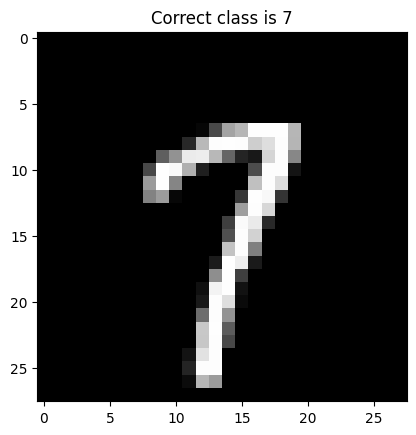

In [47]:
testI, testY = mnist_test.__getitem__(index)
fig = plt.imshow(testI.squeeze(), interpolation='nearest', cmap=plt.cm.gray)
plt.title(f"Correct class is {testY}")
plt.show()

I have written a code to plot the original image $x$, the modified image $x+r$ and the residual added $r$.

In [48]:
def plot_results(X, r, Xr, Y, l, fail=True):

    
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(25, 7))
    im1 = axes[0].imshow(X.squeeze().cpu().detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)
    axes[0].set_title(f"Original Image. Correct class is {Y}",fontsize=22)

    im3=axes[2].imshow(r.squeeze().cpu().detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)
    axes[2].set_title(f"Residual added",fontsize=22)

    if fail:
        im2=axes[1].imshow(Xr.squeeze().cpu().detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)    
        axes[1].set_title(f"Modified Image, FAILED to predict class {l.item()}",fontsize=22)
    else:
        im2=axes[1].imshow(Xr.squeeze().cpu().detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)    
        axes[1].set_title(f"Modified Image, PREDICTED class {l.item()}",fontsize=22)

    # Add a single colorbar for all subplots
    cbar = fig.colorbar(im3, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label('Intensity (0 to 1)')

    # Show the plots
    plt.show()

Here we will code the proposed method. Complete the code where you see `XXXXXXX`.

Please be advised that the `torch.optim.LBFGS` optimizer is designed to work with a `closure` for computing the loss and gradients multiple times during optimization, which is essential for second-order methods.

The closure is a callable function passed to LBFGS that recomputes the loss and its gradients multiple times during a single optimization step.
To work correctly, we need to call `optimizer.zero_grad()` to clear old gradients before calculating new ones.

Please note that SGD or Adam don't require a closure because they update the parameters based on the current gradient in a single step.

More info here: https://pytorch.org/docs/stable/optim.html

The true class is 7, the new class will be 1
Iter 20/300, Value of c: 0.005438
Iter 40/300, Value of c: 0.002957
Iter 60/300, Value of c: 0.001608
Found c = 0.001186 satisfying f(x + r) = l
Optimization succeeded with c = 0.001186 in 71 iterations
Norm Perturbation |r|: 21.818920135498047


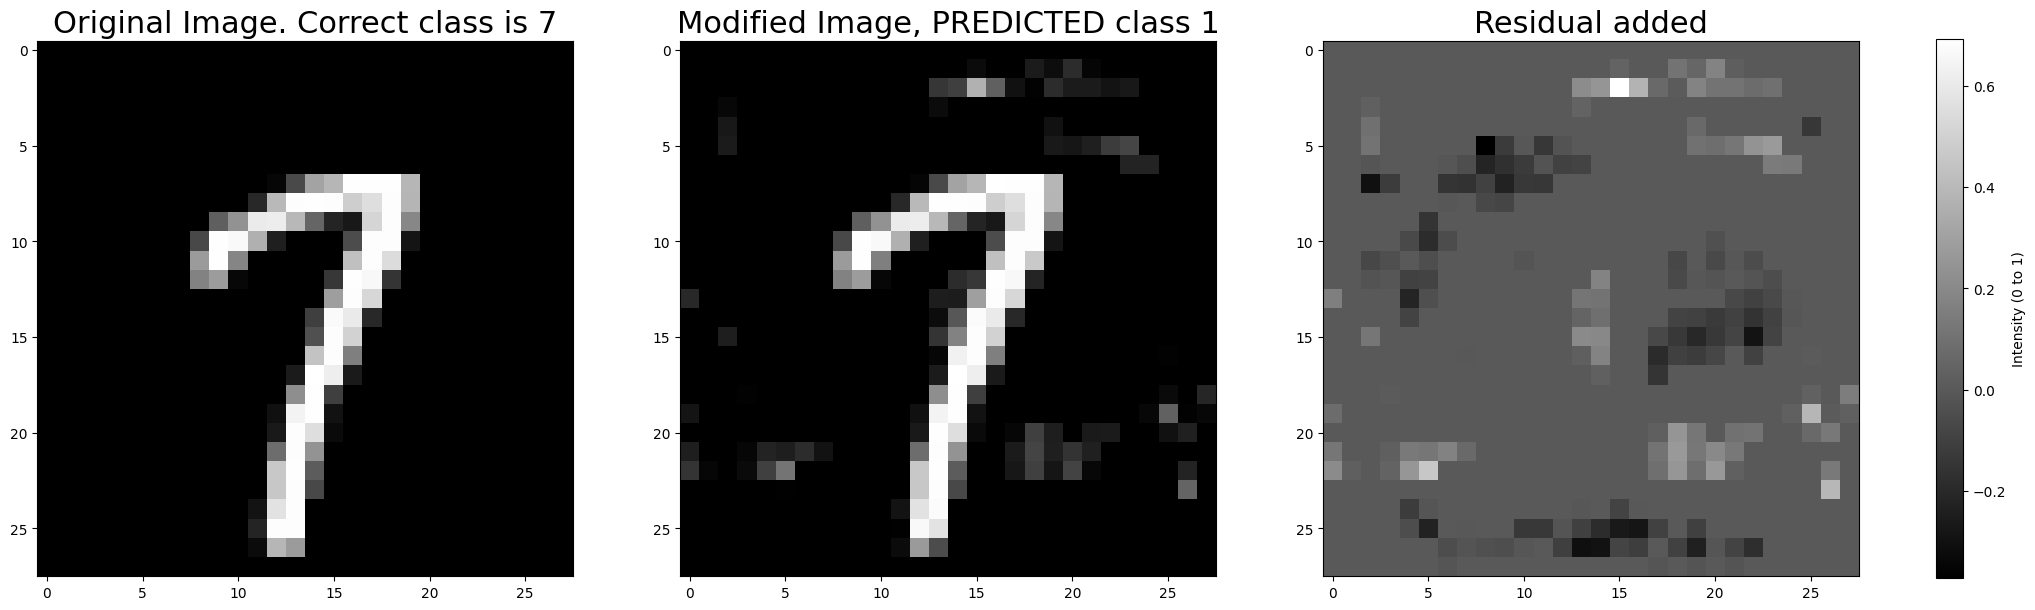

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
x = x.to(device)
testI=testI.to(device)
r = torch.zeros_like(testI, requires_grad=True, device=device)  # Initialize r as zero
label= 1 # manually chosen target class label different from true one
l = torch.tensor([label]).to(device)  
l=l.to(device)
l = l.view(1) # to have a batch size equal to 1 and work with CrossEntropy loss
print(f"The true class is {testY}, the new class will be {l[0]}")


# Define the loss function
def objective(c, r, x, l):
    pred = model(x + r)
    loss = loss_model(pred, l)
    loss += c * torch.norm(r, p=1)
    return loss


# Line search to find the minimum c > 0
c = initial_c
iter=0
while (c >= max_c) and (iter <= max_iter_search):    
    # Define the optimizer (Box-Constrained L-BFGS)

    optimizerLBFGS = optim.LBFGS([r], lr=lr_LBFGS, max_iter=max_iter_LBFGS)
    # optimizerLBFGS = optim.SGD([r], lr=0.01)

    def closure():
      optimizerLBFGS.zero_grad()
      loss = objective(c, r, testI, l)
      loss.backward()
      return loss

    # Perform optimization
    optimizerLBFGS.step(closure)

    # Evaluate the condition f(x + r) = l
    with torch.no_grad():
        x_r = torch.clamp(testI + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
        pred = model(x_r)
        predicted_label = torch.argmax(pred, dim=1)

    # Check if the condition f(x + r) = l is satisfied
    if predicted_label == l:
        print(f"Found c = {c:.6f} satisfying f(x + r) = l")
        iter=iter+1
        break
    else:
        iter=iter+1

    # If not satisfied, increase c
    c *= mult_c # Adjust step size for line search
    if (iter) % 20 == 0:
        print(f'Iter {iter}/{max_iter_search}, Value of c: {c:.6f}')

if predicted_label != l:
    print("Failed to find c satisfying f(x + r) = l within the maximum limit of c and max number of iter.")
    #print(f"Perturbation r: {r}")
    print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")

    plot_results(testI, r, x_r, testY, l, fail=True)

else:
    print(f"Optimization succeeded with c = {c:.6f} in {iter} iterations")
    #print(f"Perturbation r: {r}")
    print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")

    plot_results(testI, r, x_r, testY, l, fail=False)

**QUESTION** Try with different images and different predicted classes (l), does the algorithm always converge ? You can test with different hyper-parameters for c. When it converges, are the images semantically similar to the original one ? Visually, would you say that they should belong to the original or new class ? What's the average distortion (norm of r) ?

Test Image 0: True class = 7, Target class = 1


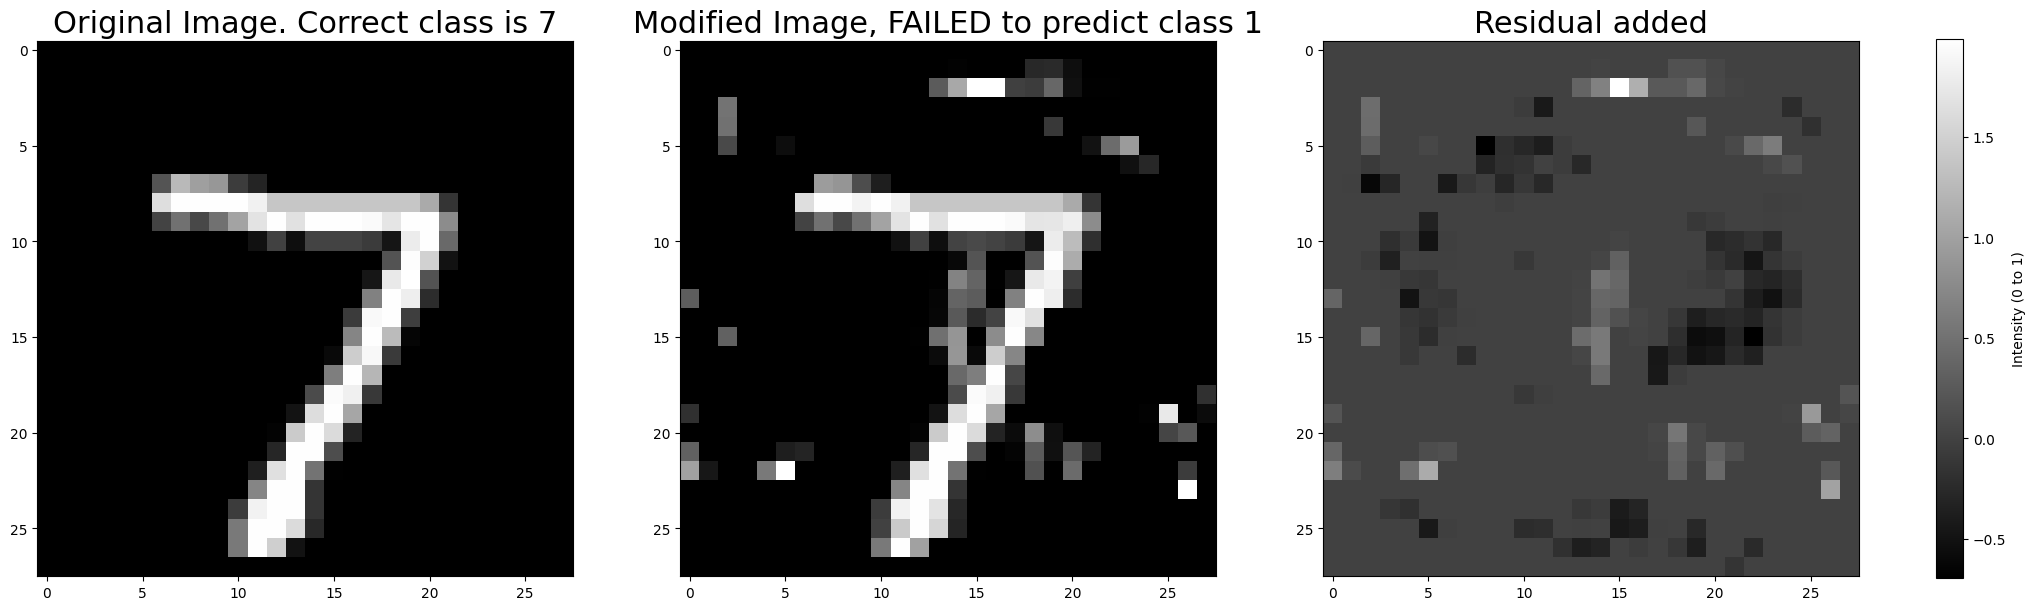

Test Image 0: True class = 7, Target class = 2
Converged for c = 0.001000


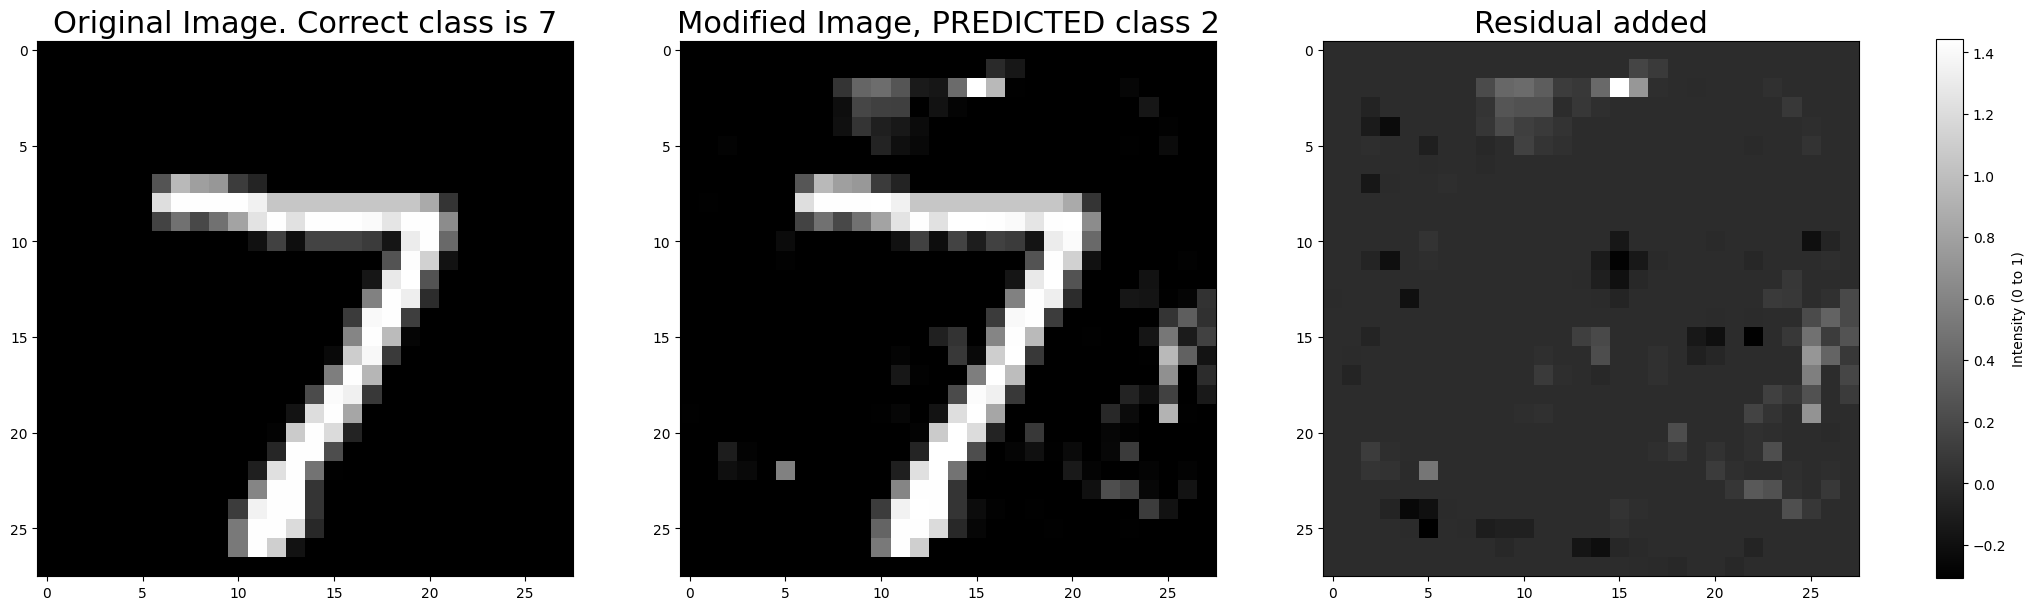

Test Image 0: True class = 7, Target class = 3
Converged for c = 0.001000


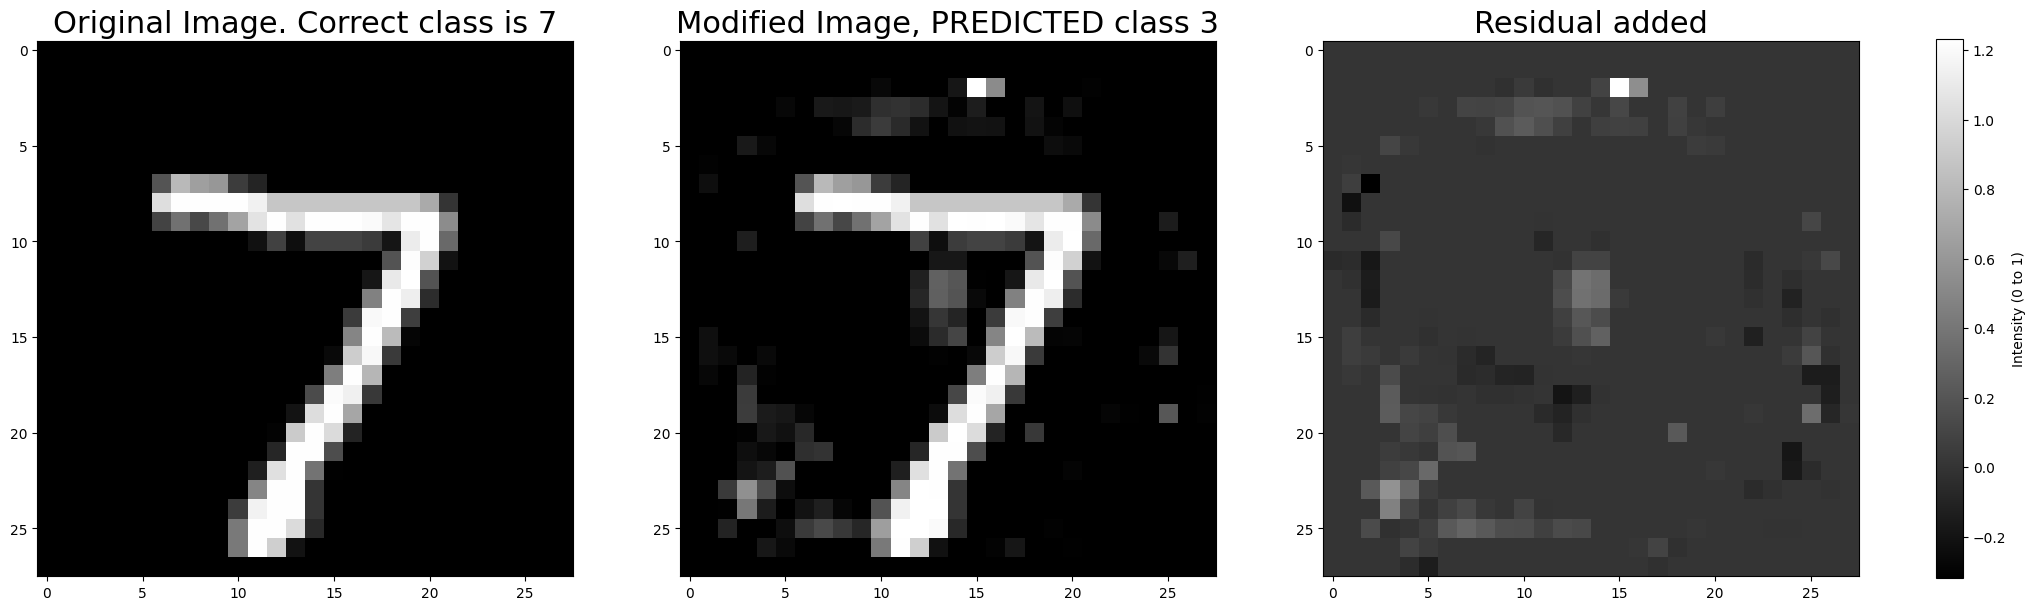

Test Image 0: True class = 7, Target class = 4


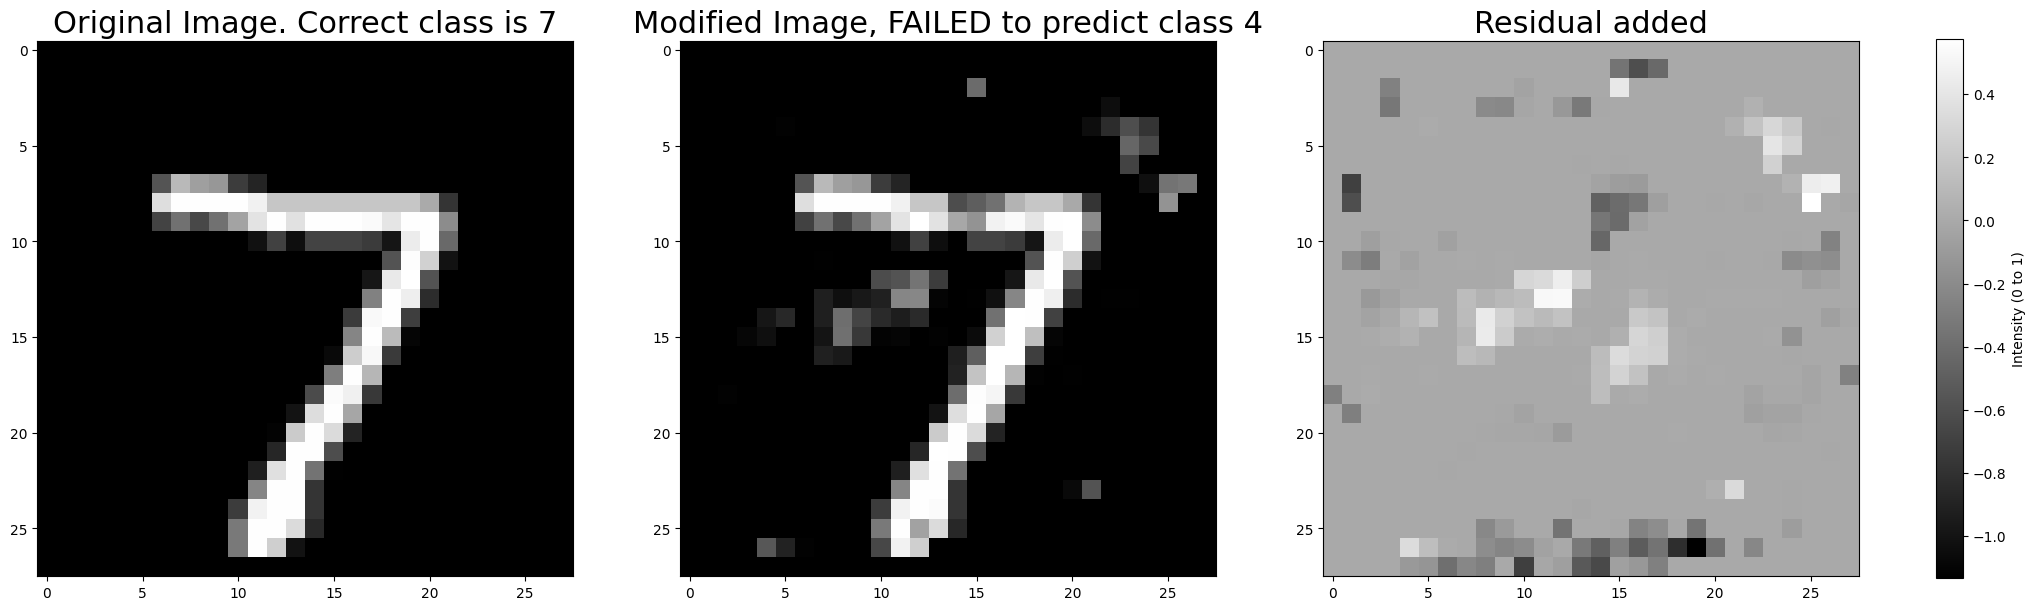

Test Image 0: True class = 7, Target class = 5
Converged for c = 0.001000


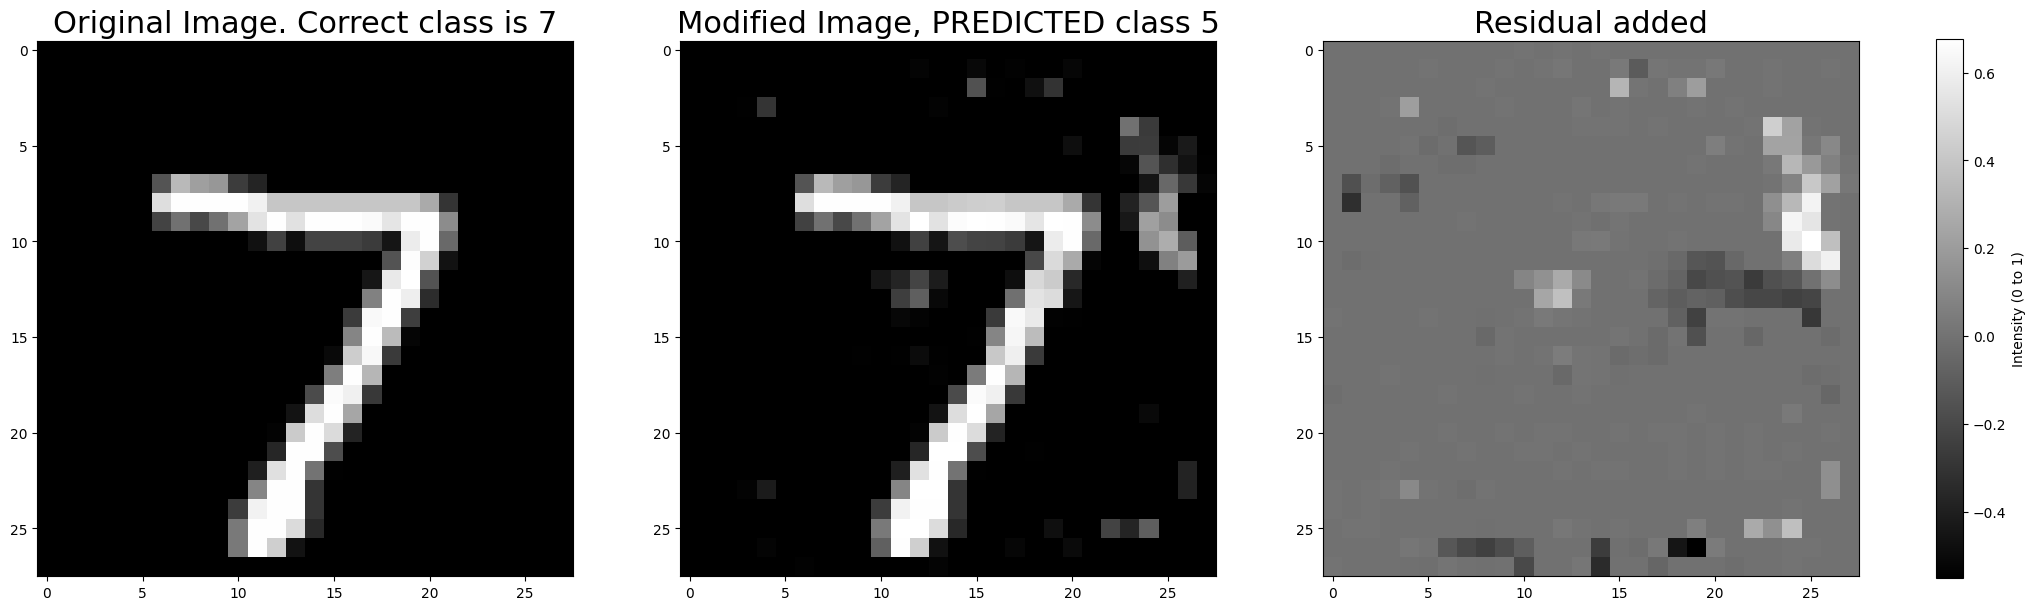

Test Image 1: True class = 2, Target class = 1
Converged for c = 0.000698
Test Image 1: True class = 2, Target class = 3
Converged for c = 0.001000
Test Image 1: True class = 2, Target class = 4
Test Image 1: True class = 2, Target class = 5
Converged for c = 0.001000
Test Image 2: True class = 1, Target class = 2
Converged for c = 0.001000
Test Image 2: True class = 1, Target class = 3
Converged for c = 0.001000
Test Image 2: True class = 1, Target class = 4
Converged for c = 0.000029
Test Image 2: True class = 1, Target class = 5
Converged for c = 0.001000
Test Image 3: True class = 0, Target class = 1
Test Image 3: True class = 0, Target class = 2
Converged for c = 0.000142
Test Image 3: True class = 0, Target class = 3
Converged for c = 0.000142
Test Image 3: True class = 0, Target class = 4
Test Image 3: True class = 0, Target class = 5
Converged for c = 0.000238
Test Image 4: True class = 4, Target class = 1
Converged for c = 0.000032
Test Image 4: True class = 4, Target class = 

In [51]:
# Parameters for adversarial example generation
max_iter_search = 100
initial_c = 0.001
max_c = 0.000001
mult_c = 0.95

epsilon_LBFGS = 1e-6
max_iter_LBFGS = 300
lr_LBFGS = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Loop over multiple images and target classes
results = []
num_tests = 5  # Number of test images
target_classes = [1, 2, 3, 4, 5]  # Target classes to evaluate

for idx in range(num_tests):
    testI, testY = mnist_test.__getitem__(idx)
    testI = testI.to(device)
    r = torch.zeros_like(testI, requires_grad=True, device=device)

    for label in target_classes:
        if label == testY:
            continue  # Skip if target class is the same as the true class
        
        l = torch.tensor([label]).to(device).view(1)
        print(f"Test Image {idx}: True class = {testY}, Target class = {l[0]}")

        # Line search for c
        c = initial_c
        iter = 0
        success = False

        while (c >= max_c) and (iter <= max_iter_search):
            optimizerLBFGS = optim.LBFGS([r], lr=lr_LBFGS, max_iter=max_iter_LBFGS)

            def closure():
                optimizerLBFGS.zero_grad()
                loss = objective(c, r, testI, l)
                loss.backward()
                return loss

            optimizerLBFGS.step(closure)

            # Evaluate the condition f(x + r) = l
            with torch.no_grad():
                x_r = torch.clamp(testI + r, 0, 1)
                pred = model(x_r)
                predicted_label = torch.argmax(pred, dim=1)

            if predicted_label == l:
                success = True
                print(f"Converged for c = {c:.6f}")
                break
            else:
                c *= mult_c
                iter += 1


        # Record results
        norm_r = torch.norm(r, p=1).item()
        x_r_np = x_r.cpu().numpy()

        results.append({
            "image_idx": idx,
            "true_class": testY,
            "target_class": l,
            "success": predicted_label == l,
            "c": c,
            "iterations": iter,
            "norm_r": norm_r,
        })

        if success and idx == 0:
            plot_results(testI, r, x_r, testY, l, fail=False)
        elif idx ==0:
            plot_results(testI, r, x_r, testY, l, fail=True)

# Summarize results
successful_cases = [r for r in results if r["success"]]
average_distortion = (
    sum(r["norm_r"] for r in successful_cases) / len(successful_cases) if successful_cases else None
)
print("\nSummary of Results:")
for result in results:
    print(result)

print(f"Average Distortion (Norm of r) for successful cases: {average_distortion}")


**Answer:**: The perturbated image are mostly similar to the original image. Moreover the algorithm does not always converge.

**Question** What if you try with different networks ? Test with al least another network (i.e., change hidden_sizes) and see if the previous conclusions are still confirmed. 

Furthermore, check the cross-network performance. This means:
- produce a set of adversarial instances for a given network (samples that are visually similar to the original class but recognised by the network as belonging to a different class)
- check if these adversarial examples are also wrongly classified by the other network

Which conclusions can you draw from these results ? Please comment on that.

In [52]:
# Parameters for adversarial example generation
max_iter_search = 100
initial_c = 0.01
max_c = 0.00001
mult_c = 0.97

epsilon_LBFGS = 1e-6
max_iter_LBFGS = 100
lr_LBFGS = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weight_decay = 0.0
num_epochs = 10
batch_size=256
learning_rate=0.001

input_size = 28*28
# Define different networks
hidden_sizes_1 = [128, 64]  # Configuration for Network 1
hidden_sizes_2 = [256, 128]  # Configuration for Network 2
output_size = 10

# Model
model1 = FullyConnectedNet(input_size, hidden_sizes_1, output_size).to(device)
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Training loop
training(model, train_loader, optimizer, num_epochs, loss_model)

evaluation(model, test_loader)

# Model
model2 = FullyConnectedNet(input_size, hidden_sizes_1, output_size).to(device)
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Training loop
training(model, train_loader, optimizer, num_epochs, loss_model)

evaluation(model, test_loader)

Epoch [1/10], Step [100/235], Loss: 0.0748
Epoch [1/10], Step [200/235], Loss: 0.0895
Epoch [2/10], Step [100/235], Loss: 0.0699
Epoch [2/10], Step [200/235], Loss: 0.0500
Epoch [3/10], Step [100/235], Loss: 0.0725
Epoch [3/10], Step [200/235], Loss: 0.0962
Epoch [4/10], Step [100/235], Loss: 0.0467
Epoch [4/10], Step [200/235], Loss: 0.0648
Epoch [5/10], Step [100/235], Loss: 0.0239
Epoch [5/10], Step [200/235], Loss: 0.0332
Epoch [6/10], Step [100/235], Loss: 0.0319
Epoch [6/10], Step [200/235], Loss: 0.0364
Epoch [7/10], Step [100/235], Loss: 0.0435
Epoch [7/10], Step [200/235], Loss: 0.0371
Epoch [8/10], Step [100/235], Loss: 0.0179
Epoch [8/10], Step [200/235], Loss: 0.0355
Epoch [9/10], Step [100/235], Loss: 0.0264
Epoch [9/10], Step [200/235], Loss: 0.0262
Epoch [10/10], Step [100/235], Loss: 0.0136
Epoch [10/10], Step [200/235], Loss: 0.0365
Accuracy of test images: 97.650000 %
Epoch [1/10], Step [100/235], Loss: 0.0186
Epoch [1/10], Step [200/235], Loss: 0.0196
Epoch [2/10], S

Test Image 0: True class = 7, Target class = 1
Converged for c = 0.002181


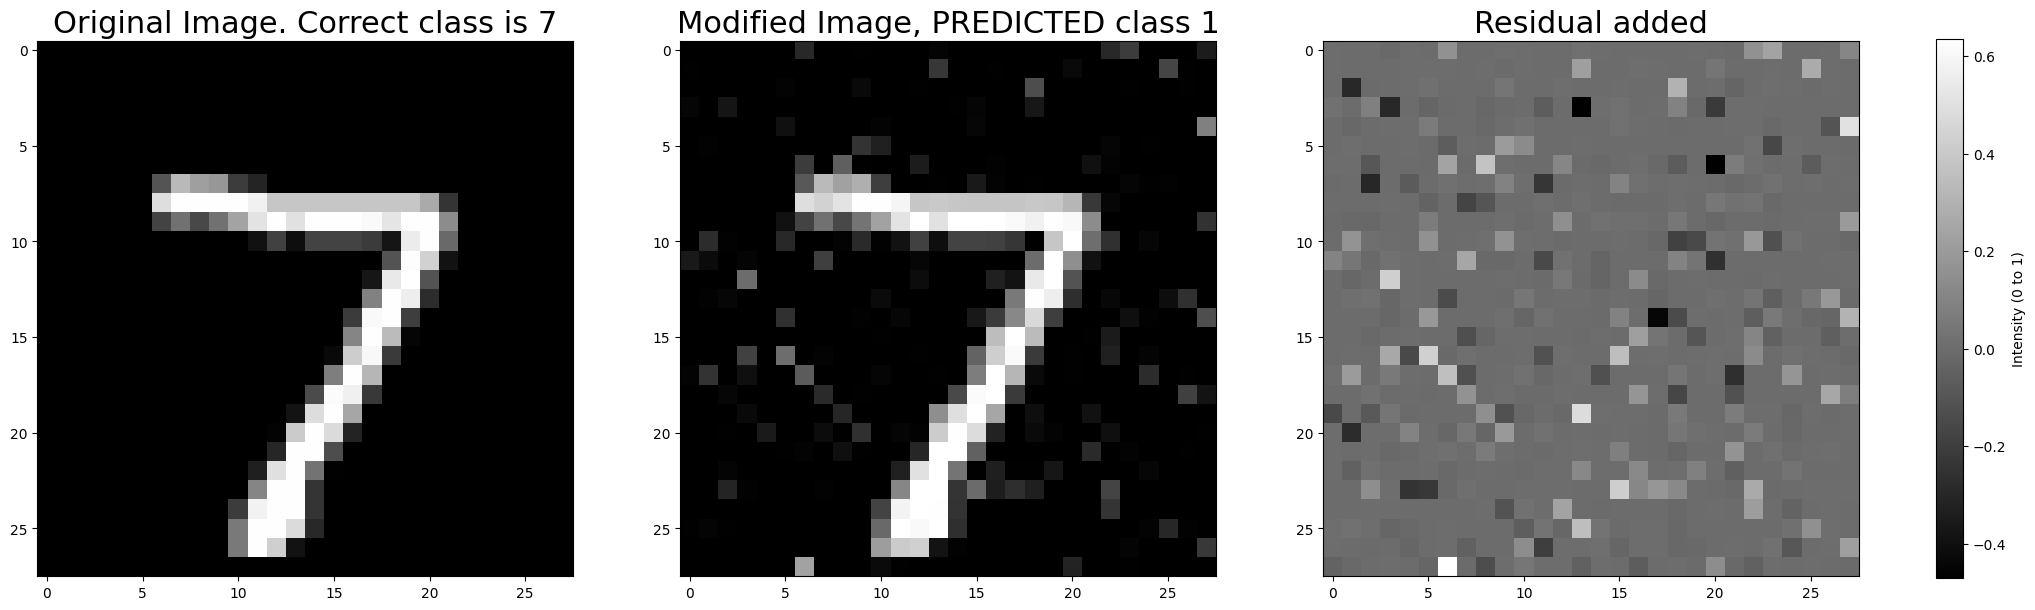

Test Image 0: True class = 7, Target class = 2
Converged for c = 0.010000


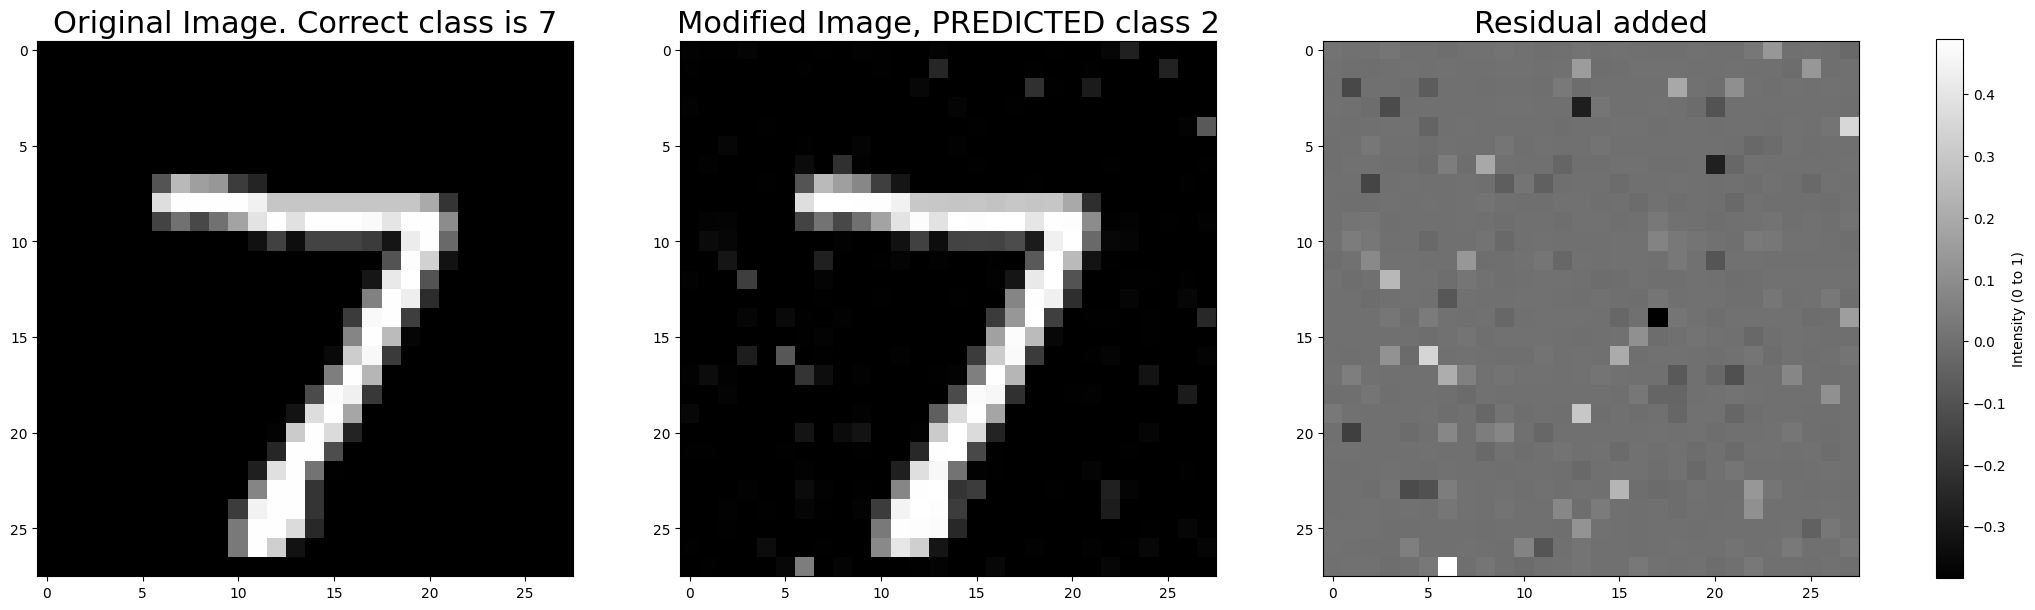

Test Image 0: True class = 7, Target class = 3
Converged for c = 0.001658


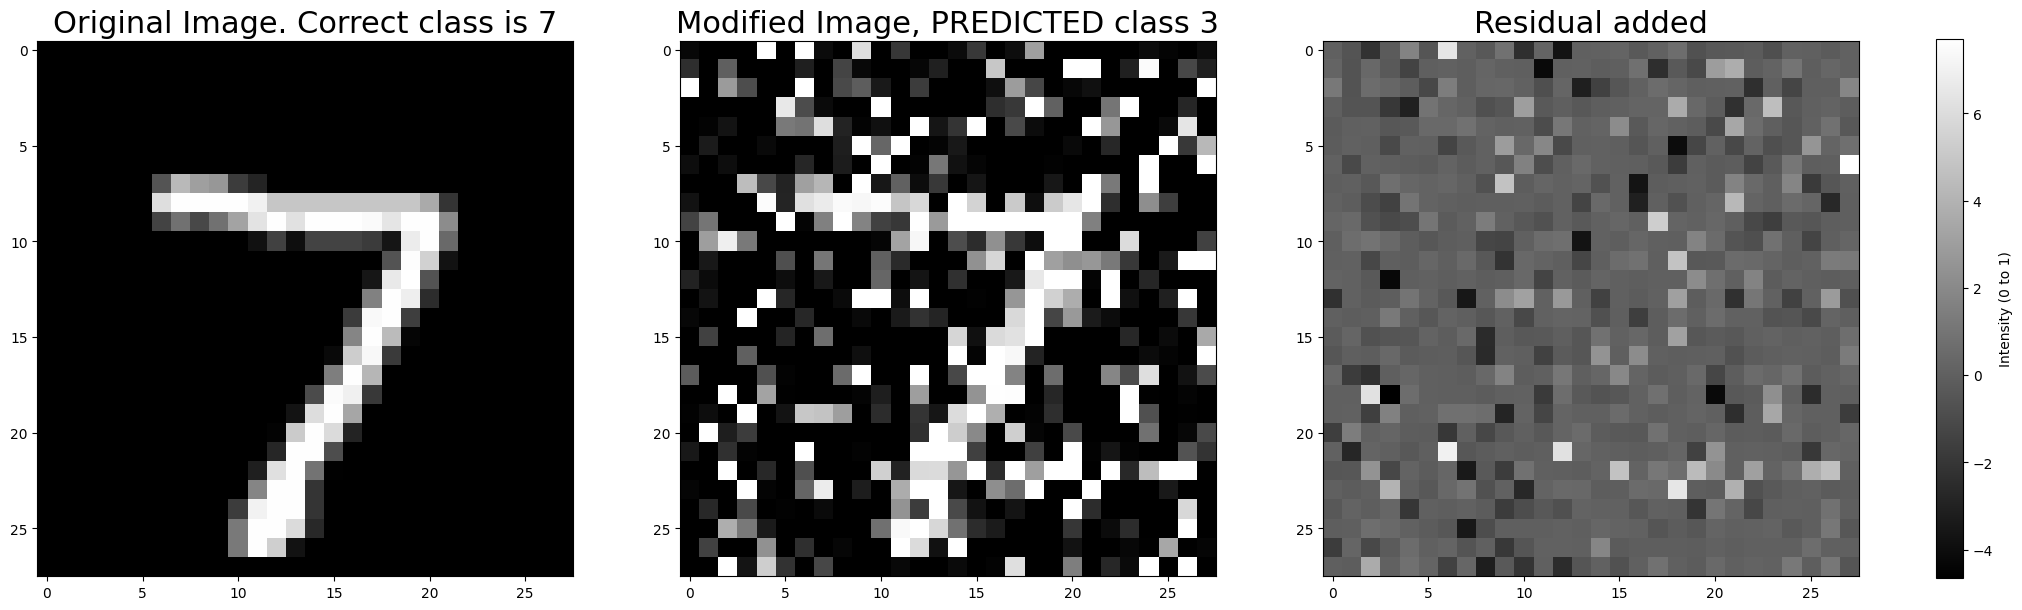

Test Image 0: True class = 7, Target class = 4
Converged for c = 0.010000


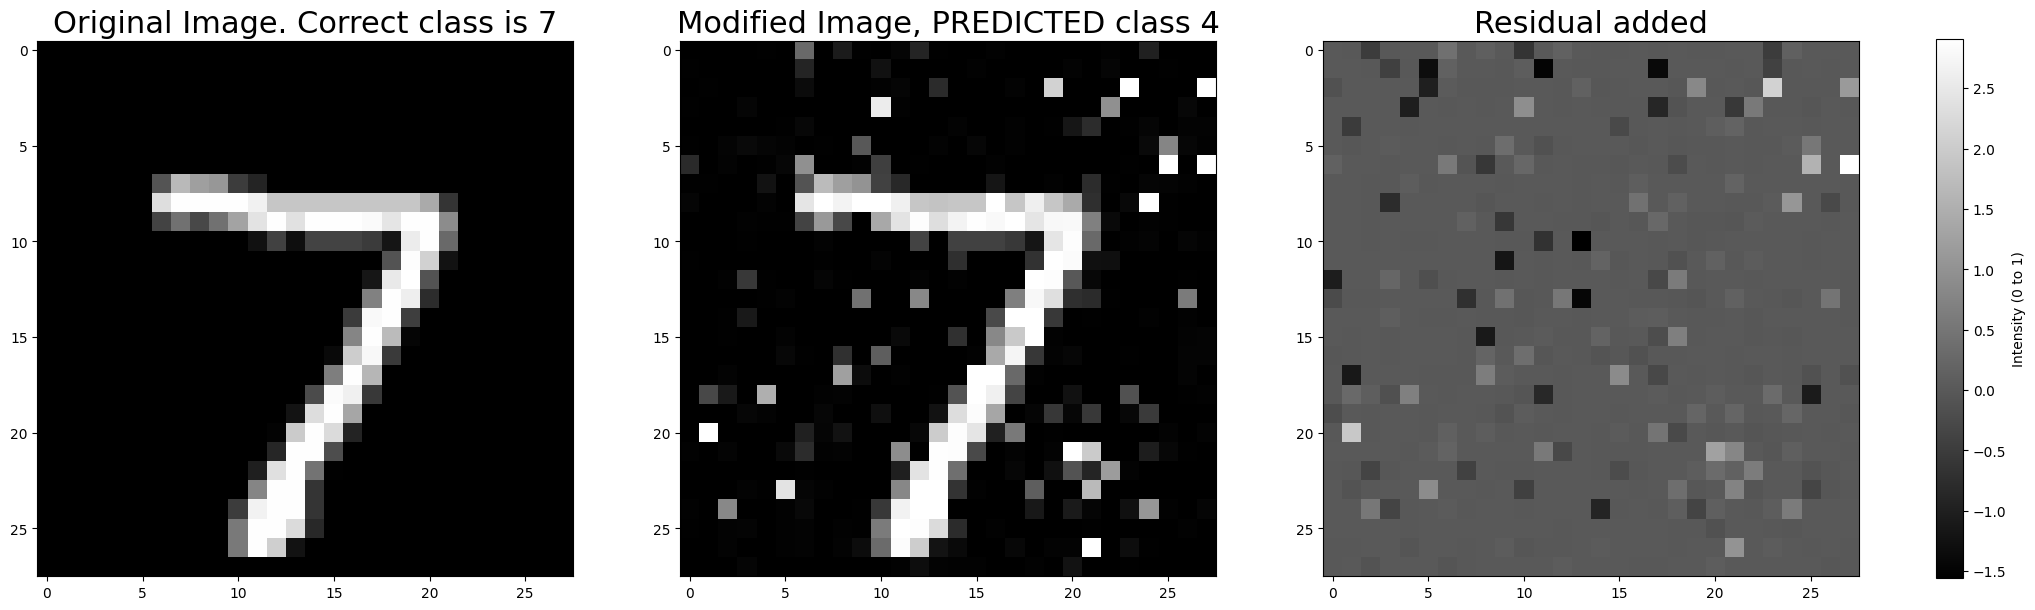

Test Image 0: True class = 7, Target class = 5
Converged for c = 0.001990


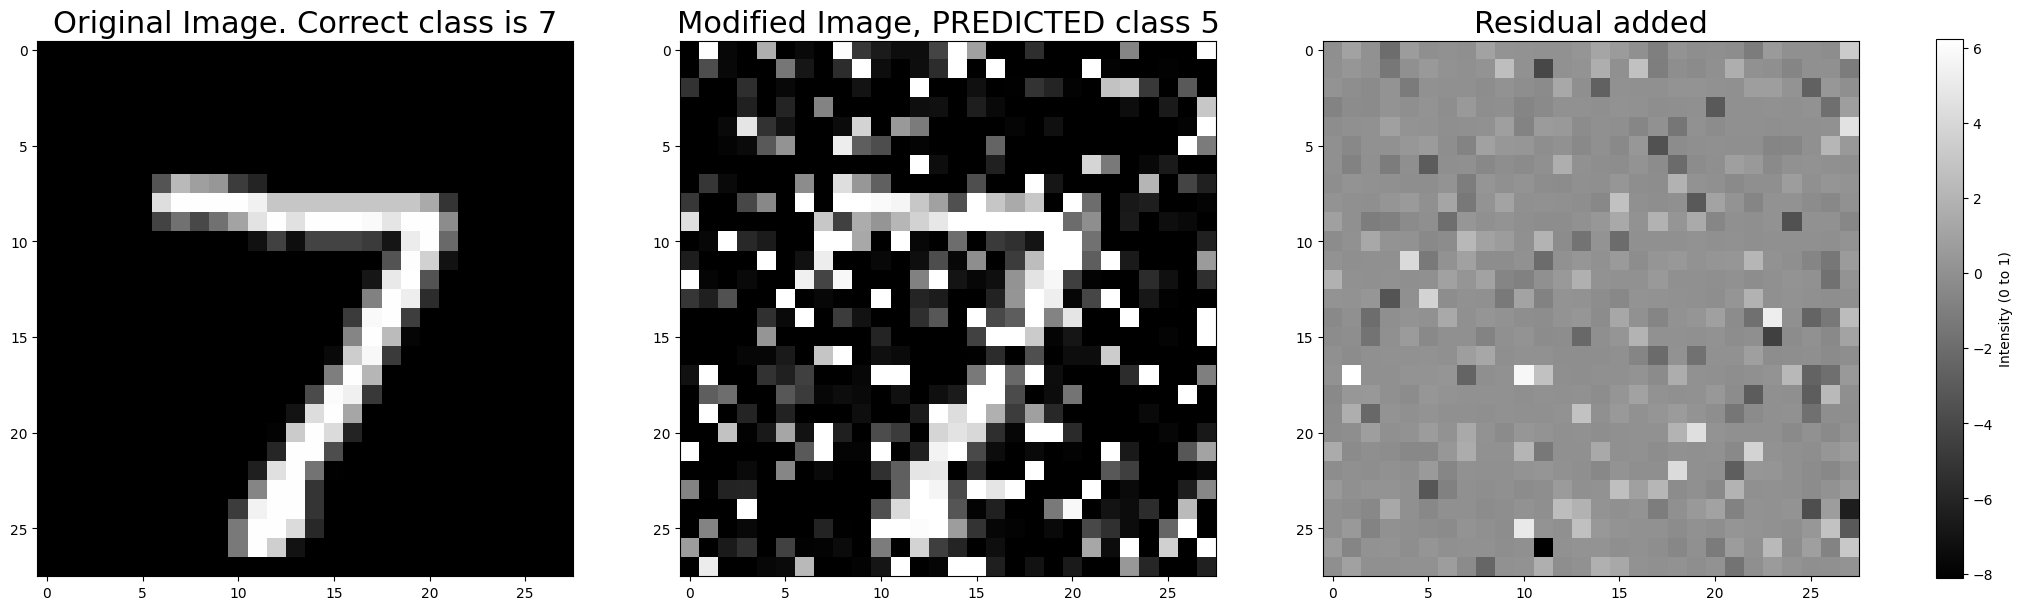

Test Image 1: True class = 2, Target class = 1
Converged for c = 0.003444
Test Image 1: True class = 2, Target class = 3
Converged for c = 0.002463
Test Image 1: True class = 2, Target class = 4
Converged for c = 0.010000
Test Image 1: True class = 2, Target class = 5
Converged for c = 0.001990
Test Image 2: True class = 1, Target class = 2
Converged for c = 0.010000
Test Image 2: True class = 1, Target class = 3
Converged for c = 0.002957
Test Image 2: True class = 1, Target class = 4
Converged for c = 0.004262
Test Image 2: True class = 1, Target class = 5
Converged for c = 0.001873
Test Image 3: True class = 0, Target class = 1
Converged for c = 0.004262
Test Image 3: True class = 0, Target class = 2
Converged for c = 0.010000
Test Image 3: True class = 0, Target class = 3
Converged for c = 0.001762
Test Image 3: True class = 0, Target class = 4
Converged for c = 0.010000
Test Image 3: True class = 0, Target class = 5
Converged for c = 0.002052
Test Image 4: True class = 4, Target c

In [53]:
# Testing across networks
results = []
num_tests = 5  # Number of test images
target_classes = [1, 2, 3, 4, 5]  # Target classes for testing

for idx in range(num_tests):
    testI, testY = mnist_test.__getitem__(idx)
    testI = testI.to(device)
    r = torch.zeros_like(testI, requires_grad=True, device=device)

    for label in target_classes:
        if label == testY:
            continue  # Skip if target class is the same as the true class
        
        l = torch.tensor([label]).to(device).view(1)
        print(f"Test Image {idx}: True class = {testY}, Target class = {l[0]}")

        # Generate adversarial example using Model 1
        model = model1
        c = initial_c
        iter = 0
        success = False

        while (c >= max_c) and (iter <= max_iter_search):
            optimizerLBFGS = optim.LBFGS([r], lr=lr_LBFGS, max_iter=max_iter_LBFGS)

            def closure():
                optimizerLBFGS.zero_grad()
                loss = objective(c, r, testI, l)
                loss.backward()
                return loss

            optimizerLBFGS.step(closure)

            with torch.no_grad():
                x_r = torch.clamp(testI + r, 0, 1)
                pred = model(x_r)
                predicted_label = torch.argmax(pred, dim=1)

            if predicted_label == l:
                success = True
                print(f"Converged for c = {c:.6f}")
                break
            else:
                c *= mult_c
                iter += 1

        # Record adversarial results for Model 1
        norm_r = torch.norm(r, p=1).item()
        results.append({
            "image_idx": idx,
            "true_class": testY,
            "target_class": l,
            "success_model1": success,
            "c": c,
            "norm_r": norm_r,
        })

        # Cross-network evaluation with Model 2
        with torch.no_grad():
            pred_model2 = model2(x_r)
            predicted_label_model2 = torch.argmax(pred_model2, dim=1)
            cross_network_success = (predicted_label_model2 == l)

        results[-1]["cross_network_success"] = cross_network_success.item()
        if idx == 0:
            plot_results(testI, r, x_r, testY, l, fail=not success)

# Summarize results
success_model1 = [r for r in results if r["success_model1"]]
cross_network_success = [r for r in success_model1 if r["cross_network_success"]]

average_distortion = (
    sum(r["norm_r"] for r in success_model1) / len(success_model1) if success_model1 else None
)

print("\nSummary of Results:")
for result in results:
    print(result)

print(f"Average Distortion (Norm of r) for Model 1 successful cases: {average_distortion}")
print(f"Cross-network success rate: {len(cross_network_success) / len(success_model1) * 100:.2f}%")


**Answer:** the cross network succes rate is very low (equals to the random noise), which means the method is very constrained to the network it has been trained on.

Instead than using L-BFGS to find adversarial examples we could also use a backpropagation method such as Adam, where you could optimize only r or both r and c. 

**Question** Change the previous code to use Adam instead than L-BFGS for the optimization. This means that you don't do anymore a line-search to find the minimum $c$ (no more closure). You can either fix $c$ and estimate only $r$ or estimate both. Try these two solutions and comment on that. Does it work properly ? If not, try to change the loss function. Would you add a regularization term ? If yes, which one and why ? Does it work better ? Please comment on that.

Test Image 0: True class = 7, Target class = 1
Converged for c = 0.002181


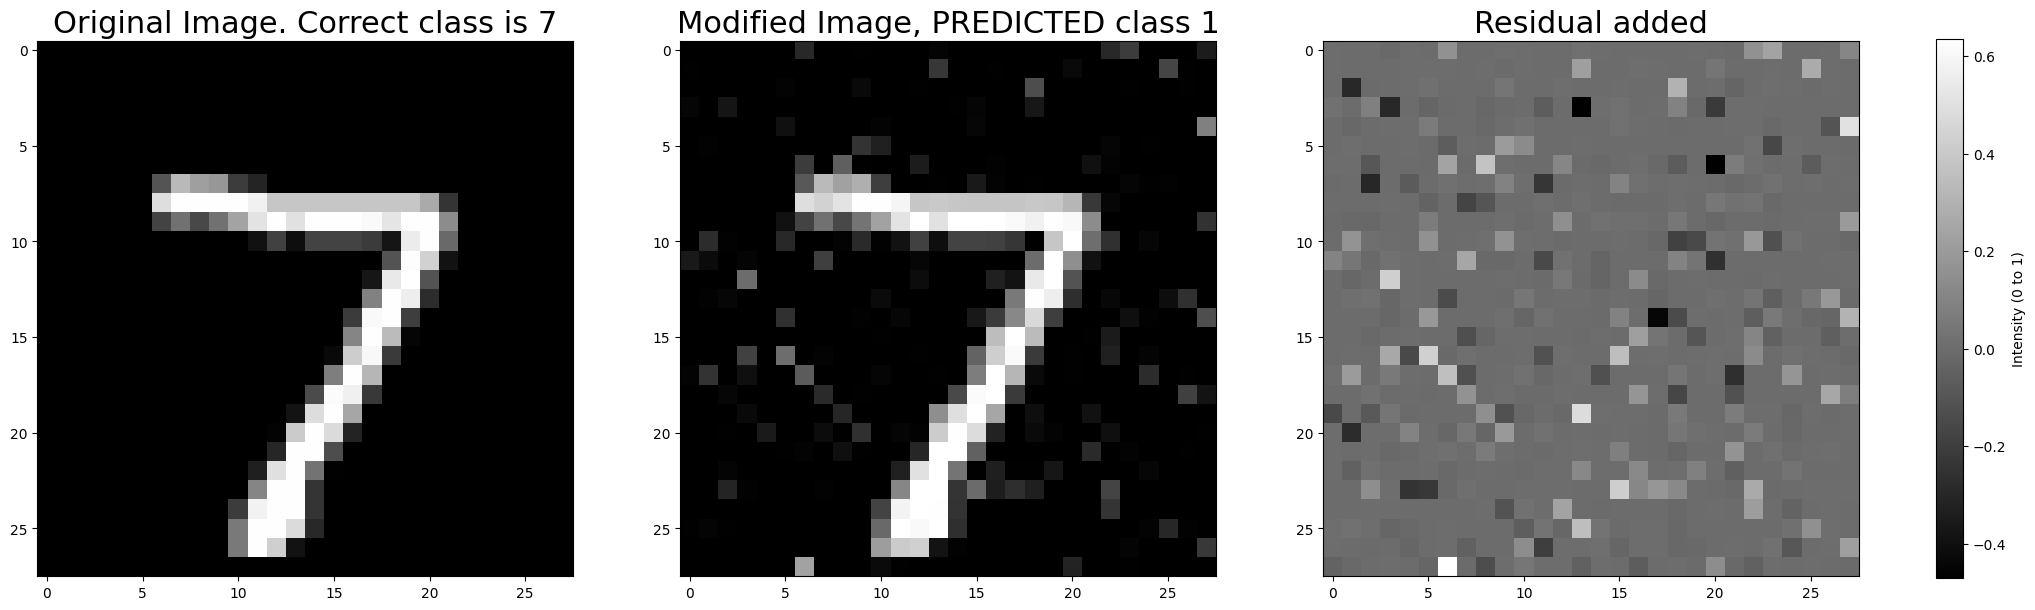

Test Image 0: True class = 7, Target class = 2
Converged for c = 0.010000


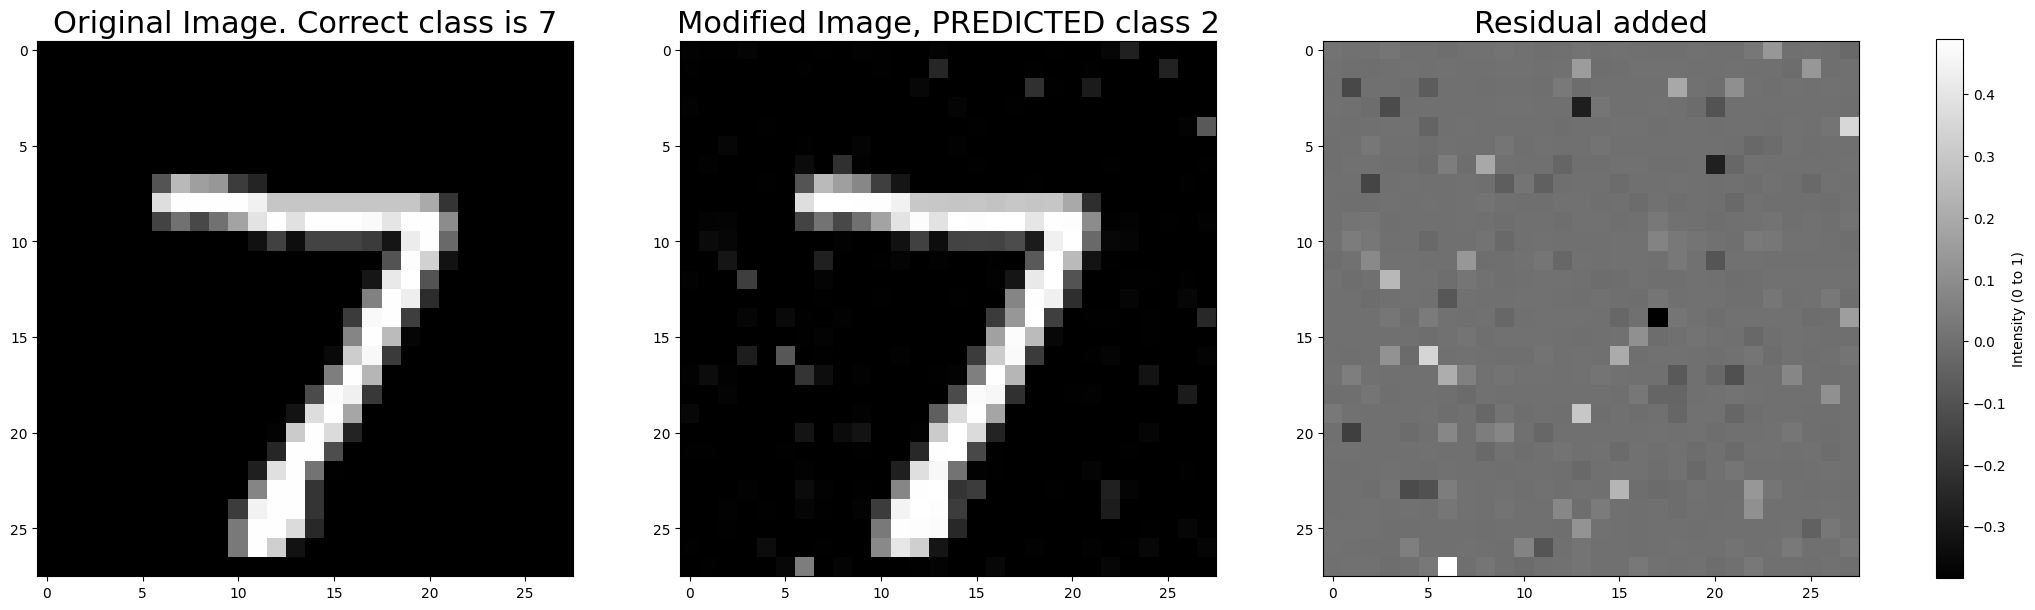

Test Image 0: True class = 7, Target class = 3
Converged for c = 0.001658


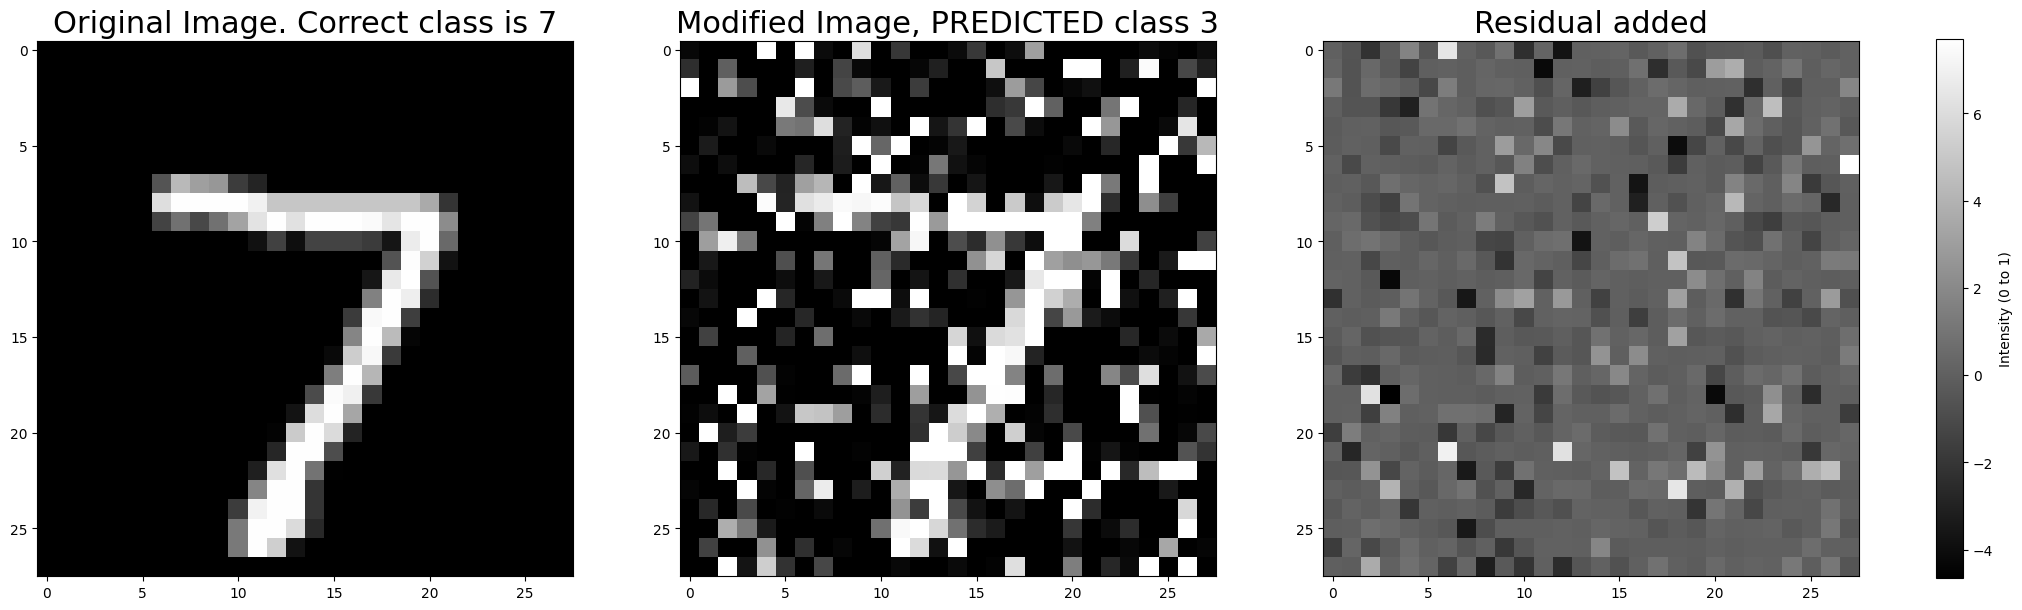

Test Image 0: True class = 7, Target class = 4
Converged for c = 0.010000


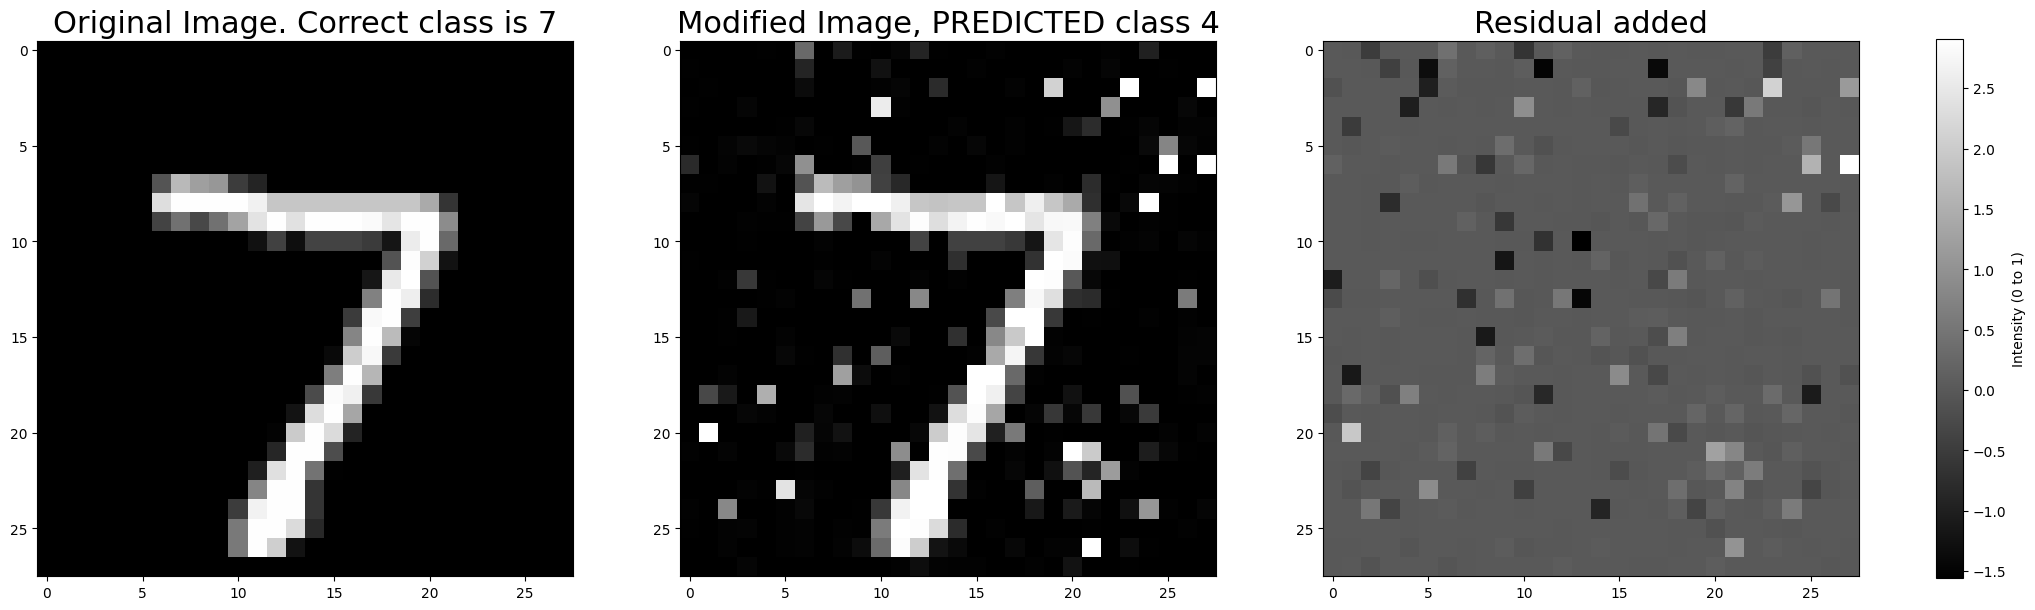

Test Image 0: True class = 7, Target class = 5
Converged for c = 0.001990


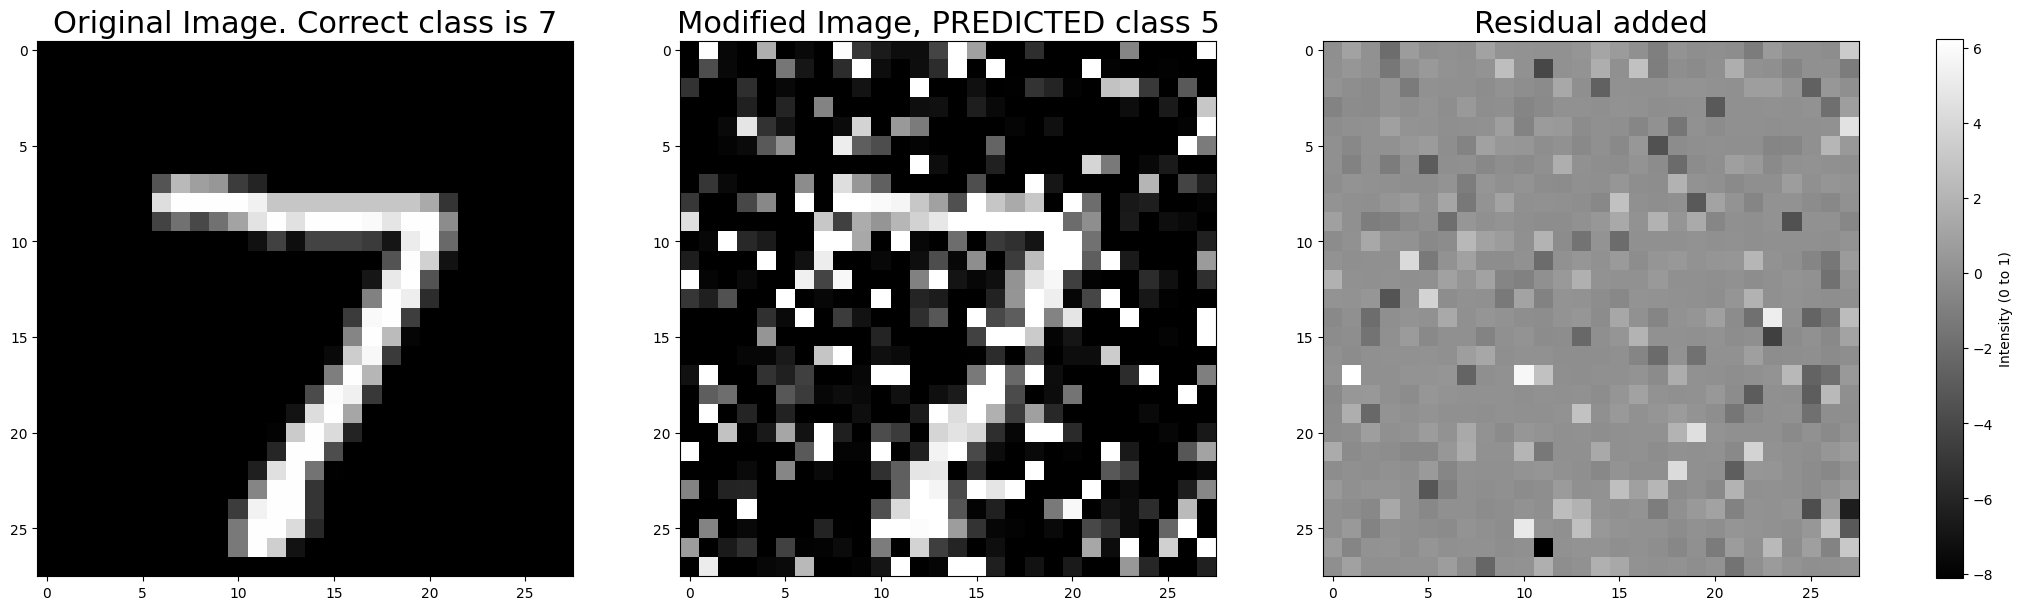

Test Image 1: True class = 2, Target class = 1
Converged for c = 0.003444
Test Image 1: True class = 2, Target class = 3
Converged for c = 0.002463
Test Image 1: True class = 2, Target class = 4
Converged for c = 0.010000
Test Image 1: True class = 2, Target class = 5
Converged for c = 0.001990
Test Image 2: True class = 1, Target class = 2
Converged for c = 0.010000
Test Image 2: True class = 1, Target class = 3
Converged for c = 0.002957
Test Image 2: True class = 1, Target class = 4
Converged for c = 0.004262
Test Image 2: True class = 1, Target class = 5
Converged for c = 0.001873
Test Image 3: True class = 0, Target class = 1
Converged for c = 0.004262
Test Image 3: True class = 0, Target class = 2
Converged for c = 0.010000
Test Image 3: True class = 0, Target class = 3
Converged for c = 0.001762
Test Image 3: True class = 0, Target class = 4
Converged for c = 0.010000
Test Image 3: True class = 0, Target class = 5
Converged for c = 0.002052
Test Image 4: True class = 4, Target c

In [54]:
# Testing across networks
results = []
num_tests = 5  # Number of test images
target_classes = [1, 2, 3, 4, 5]  # Target classes for testing

for idx in range(num_tests):
    testI, testY = mnist_test.__getitem__(idx)
    testI = testI.to(device)
    r = torch.zeros_like(testI, requires_grad=True, device=device)

    for label in target_classes:
        if label == testY:
            continue  # Skip if target class is the same as the true class
        
        l = torch.tensor([label]).to(device).view(1)
        print(f"Test Image {idx}: True class = {testY}, Target class = {l[0]}")

        # Generate adversarial example using Model 1
        model = model1
        c = initial_c
        iter = 0
        success = False

        while (c >= max_c) and (iter <= max_iter_search):
            optimizerLBFGS = optim.LBFGS([r], lr=lr_LBFGS, max_iter=max_iter_LBFGS)

            def closure():
                optimizerLBFGS.zero_grad()
                loss = objective(c, r, testI, l)
                loss.backward()
                return loss

            optimizerLBFGS.step(closure)

            with torch.no_grad():
                x_r = torch.clamp(testI + r, 0, 1)
                pred = model(x_r)
                predicted_label = torch.argmax(pred, dim=1)

            if predicted_label == l:
                success = True
                print(f"Converged for c = {c:.6f}")
                break
            else:
                c *= mult_c
                iter += 1

        # Record adversarial results for Model 1
        norm_r = torch.norm(r, p=1).item()
        results.append({
            "image_idx": idx,
            "true_class": testY,
            "target_class": l,
            "success_model1": success,
            "c": c,
            "norm_r": norm_r,
        })

        # Cross-network evaluation with Model 2
        with torch.no_grad():
            pred_model2 = model2(x_r)
            predicted_label_model2 = torch.argmax(pred_model2, dim=1)
            cross_network_success = (predicted_label_model2 == l)
        
        results[-1]["cross_network_success"] = cross_network_success.item()
        if idx == 0:
            plot_results(testI, r, x_r, testY, l, fail=not success)

# Summarize results
success_model1 = [r for r in results if r["success_model1"]]
cross_network_success = [r for r in success_model1 if r["cross_network_success"]]

average_distortion = (
    sum(r["norm_r"] for r in success_model1) / len(success_model1) if success_model1 else None
)

print("\nSummary of Results:")
for result in results:
    print(result)

print(f"Average Distortion (Norm of r) for Model 1 successful cases: {average_distortion}")
print(f"Cross-network success rate: {len(cross_network_success) / len(success_model1) * 100:.2f}%")


**Answer**: With the new optimization algorithm, the average distortion seems to be higher, but most of the time, the algorithm still converges.

# Fast Gradient Sign Attack (FGSM)

Another famous method to create adversarial examples is Fast Gradient Sign Attack (FGSM). Let $\theta$ be the parameters of a model, x the input image to the model, y its class and J(θ, x, y) the cost used to train the neural network. Usually, when training a model, we compute the gradient of the cost function with respect to the parameters of the model and update them based on the oppositve (i.e., negative) direction of the gradient to decrease the loss. Here, we can replicate the same reasoning but using the pixel values of the input image instead than the model's parameters and using the gradient direction (i.e., positve) to actually maximize the loss. The idea is thus to modify the pixel values so that the loss is maximized and not minimized. In this way, the perturbation should change the image so that it will be misclassified by the model. In order to keep the changes small, possibly imperceptible to naked eye, we only use the sign of the gradient and multiply it by a small $\epsilon$ value. Mathematically, the adversarial example is estimated using:
 $$x_r =x + \epsilon \text{sign}(\Delta_x J(\theta, x, y))$$

 The gradient can easily be computed using backpropagation (Adam).


[*]` Ian J. Goodfellow, Jonathon Shlens & Christian Szegedy Explaining and harnessing adversarial examples. ICLR. 2015`

Let's load an image.

In [55]:
# Parameters
index=10
testI, testY = mnist_test.__getitem__(index)
X = testI.unsqueeze(0).to(device)
print(X.shape)
X.requires_grad = True # Important for attack
Y=torch.tensor([testY]).to(device)

torch.Size([1, 1, 28, 28])


And plot it.

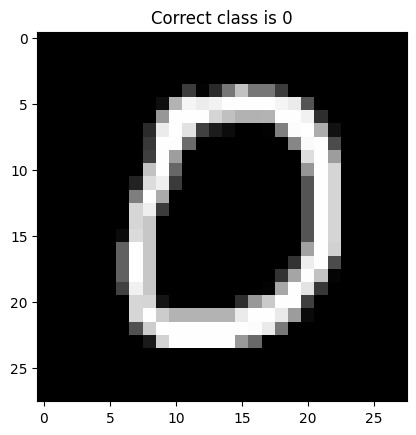

In [56]:
fig = plt.imshow(testI.squeeze(), interpolation='nearest', cmap=plt.cm.gray)
plt.title(f"Correct class is {testY}")
plt.show()

Complete the code by fixing a `eps`value.

Original Class: 2, Perturbed Class: 2
Optimization failed
Norm Perturbation |r|: 78.39937591552734


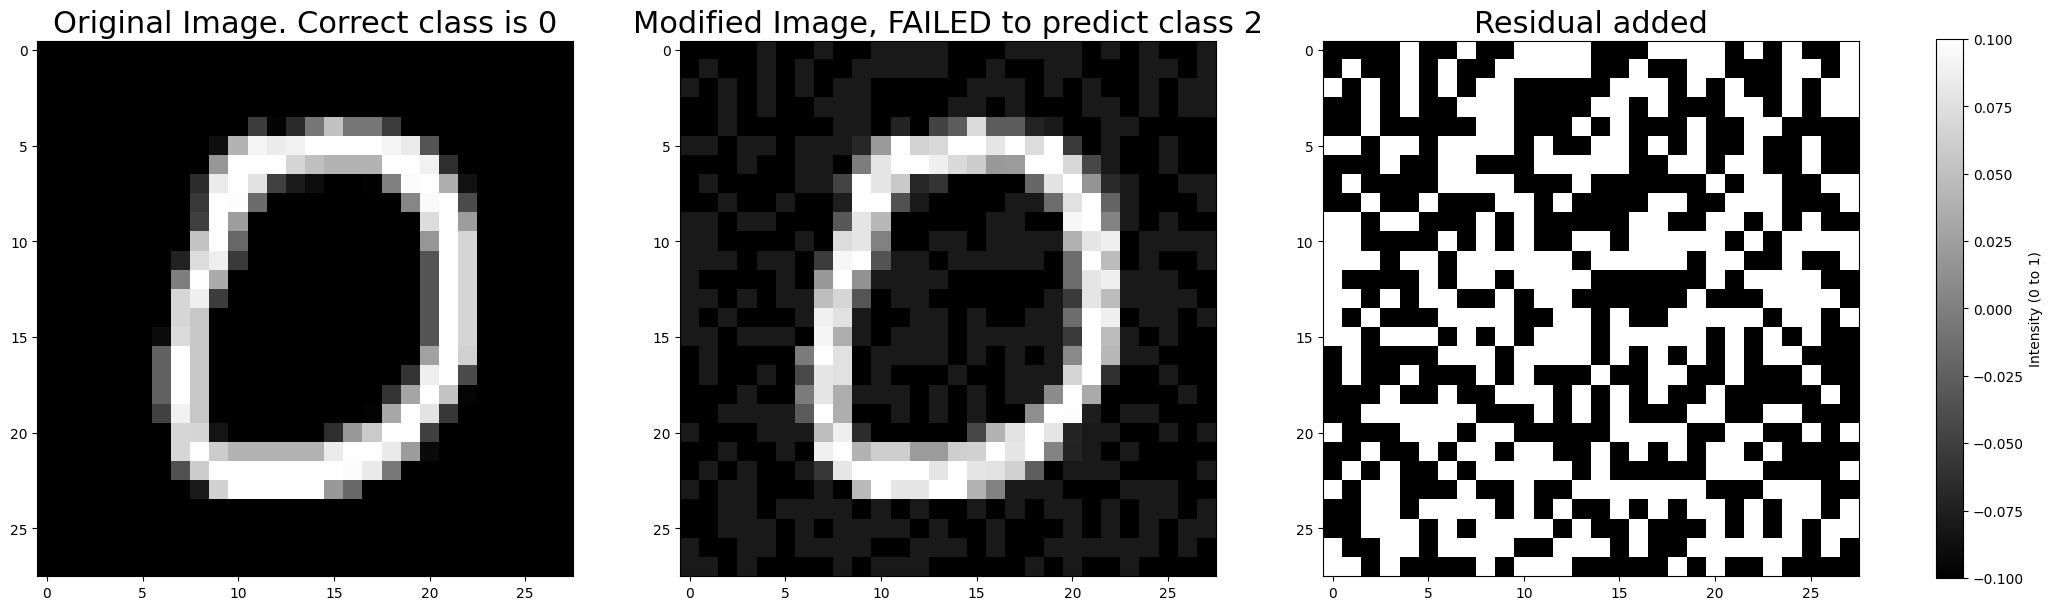

In [57]:
eps = 0.1 # perturbation size

# Forward pass of X through the model
pred_original = model(X)  
original_class = torch.argmax(pred_original, dim=1)

# Compute loss
cost = loss_model(pred_original, Y)

# Zero existing (previous) gradients
model.zero_grad()

# Compute gradients
cost.backward()

# FGSM attack code
Xr = X + eps*X.grad.data.sign()
Xr = torch.clamp(Xr, 0, 1)

# Re-classify the perturbed image
pred_perturbed = model(Xr)
perturbed_class= torch.argmax(pred_perturbed, dim=1)

# Print results
print(f"Original Class: {original_class.item()}, Perturbed Class: {perturbed_class.item()}")

r=eps*X.grad.data.sign()

if original_class.item()==perturbed_class.item():
    print(f"Optimization failed")
    print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
    plot_results(X, r, Xr, testY, perturbed_class, fail=True)   
else:
    print(f"Optimization succesfull")
    print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
    plot_results(X, r, Xr, testY, perturbed_class, fail=False)

Now, to find the best `eps`value, you will code a function and evalute the successful rate for each `eps`value (number of images where an adversarial examples has been successfully created). 

**Question**: What's the best `eps`value ? Are the changes imperceptible to a naked human eye ?

Using epsilon: 0.01 we succesfully create 94.54 % adversariale examples


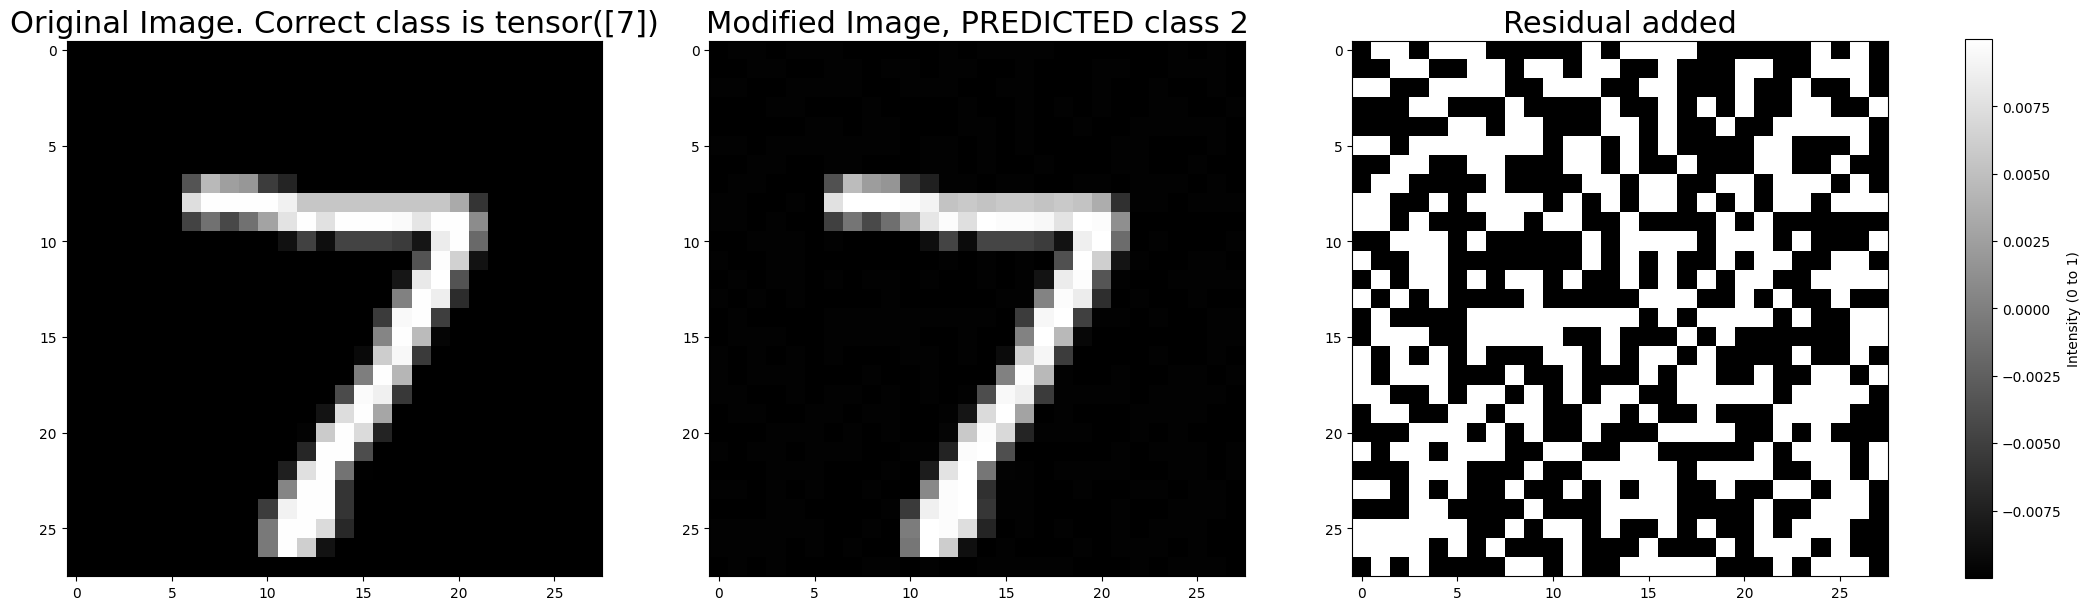

Using epsilon: 0.05 we succesfully create 98.99 % adversariale examples


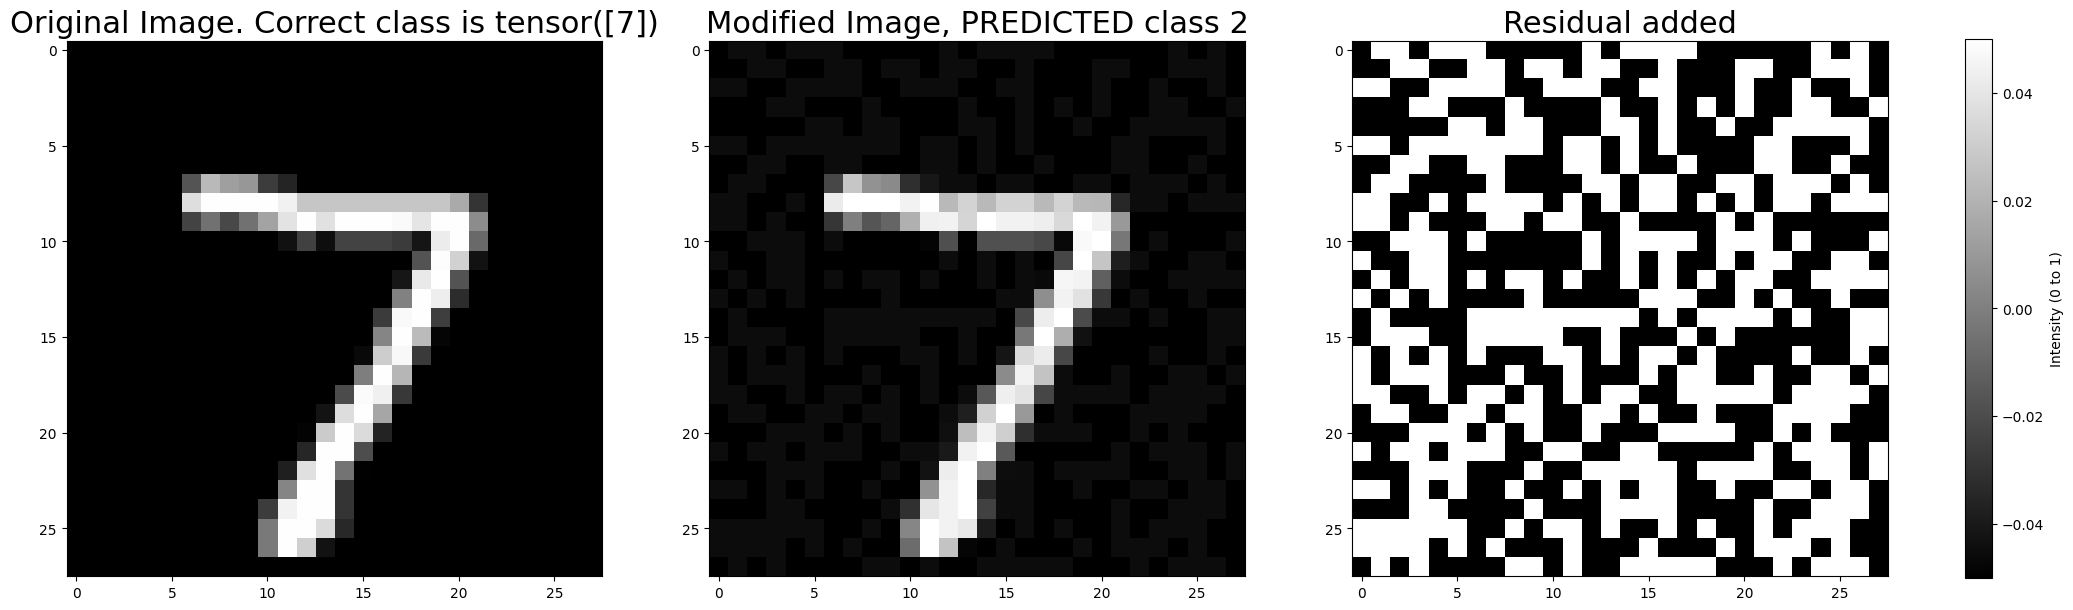

Using epsilon: 0.1 we succesfully create 99.91 % adversariale examples


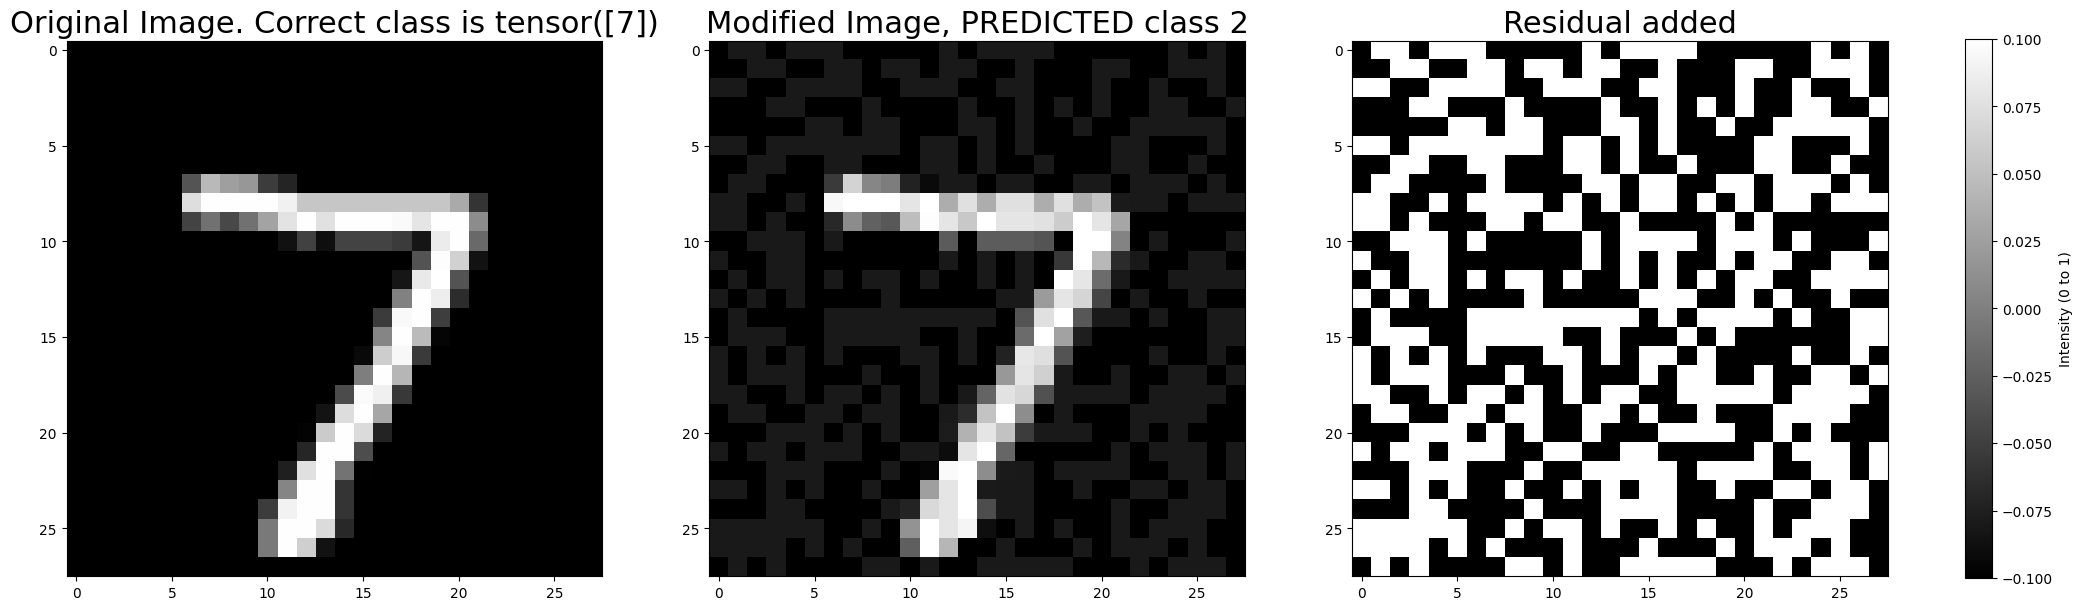

Using epsilon: 0.2 we succesfully create 100.0 % adversariale examples


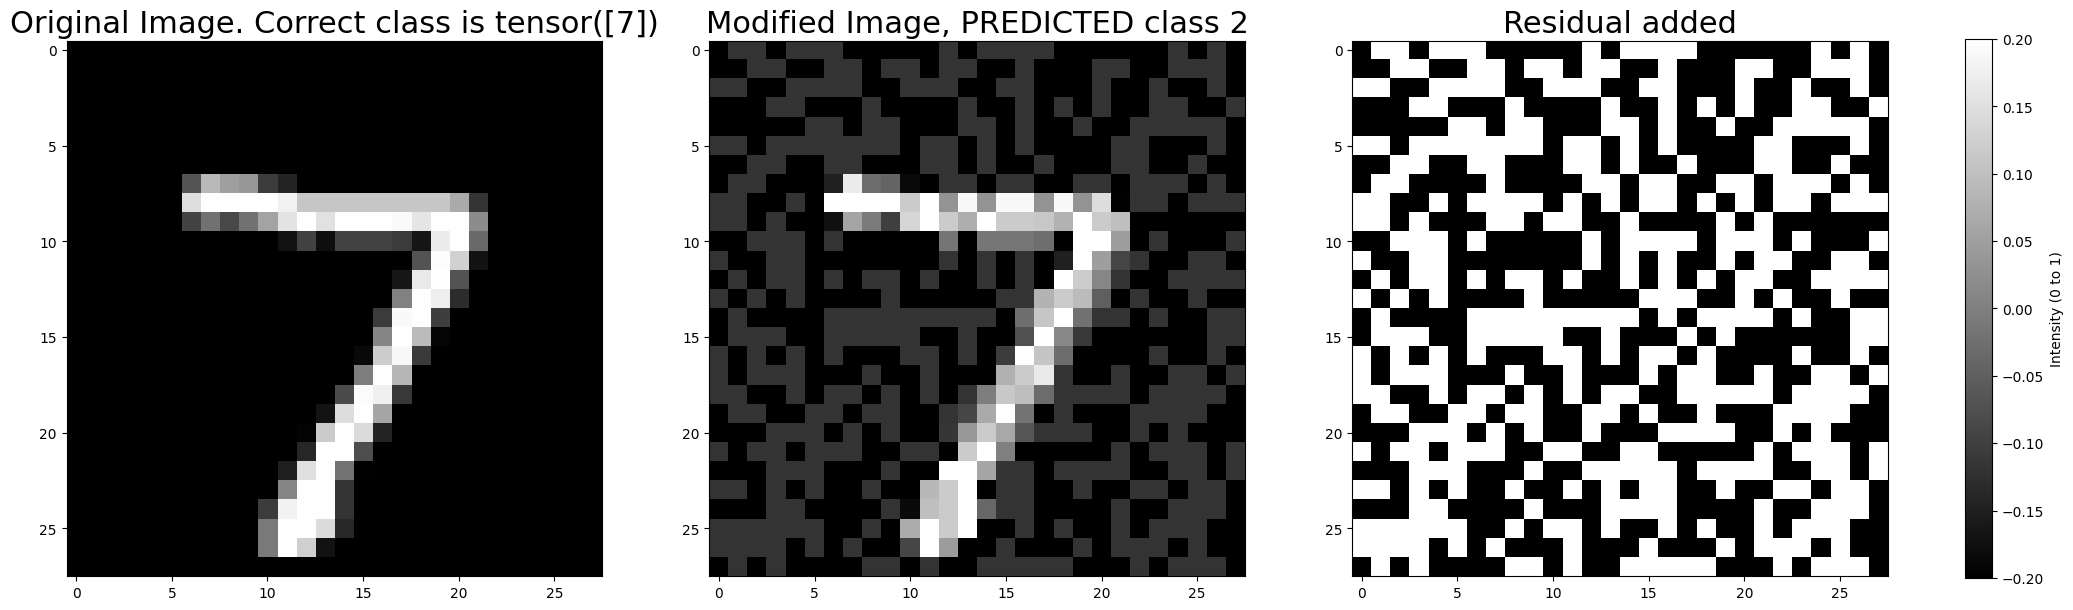

In [58]:
def fgsm_attack(X, Y, model, loss_model, eps):
    
    # Forward pass of X through the model
    pred_original = model(X)
    original_class=torch.argmax(pred_original, dim=1)

    # Compute loss
    cost = loss_model(pred_original, Y)

    # Zero existing (previous) gradients
    model.zero_grad()

    # Compute gradients
    cost.backward()

    # FGSM attack code
    Xr = X + eps*X.grad.data.sign()
    Xr = torch.clamp(Xr, 0, 1)

    # Re-classify the perturbed image
    pred_perturbed = model(Xr)
    perturbed_class= torch.argmax(pred_perturbed, dim=1)

    r=eps*X.grad.data.sign()

    return Xr, perturbed_class, r

list_eps =  [0.01,0.05, 0.1, 0.2] # perturbation size

for eps in list_eps:
    adv_examples = []
    succes=0
    # Loop over all examples in test set
    for X_batch, Y_batch in test_loader:  # Iterate through batches
        for X, Y in zip(X_batch, Y_batch):
            
            # Send the data and label to the device
            X, Y = X.to(device), Y.to(device)
            X = X.unsqueeze(0)
            Y = Y.unsqueeze(0)
            X.requires_grad = True

            # Call
            Xr, perturbed_class, r = fgsm_attack(X, Y, model, loss_model, eps)
            
            # Check for success
            if Y != perturbed_class.item():
                adv_ex = Xr.squeeze().detach().cpu().numpy()
                adv_examples.append((X, r,  Xr, Y, perturbed_class))
                succes+=1

    # Calculate final accuracy for this epsilon
    Adv_acc = 100.0 * succes / len(test_loader.dataset)
    print(f"Using epsilon: {eps} we succesfully create {Adv_acc} % adversariale examples")   

    # Plot one example
    index=0
    plot_results(adv_examples[index][0], adv_examples[index][1], adv_examples[index][2], adv_examples[index][3], adv_examples[index][4], fail=False)

With epsilone equal to 1, the added details are not perceptible to the naked eye.